# ERP CORE N170: Robust Preprocessing + DSS

This notebook demonstrates a full EEG analysis pipeline combining:

1. **Robust Preprocessing** from de Cheveigné & Arzounian (2018) *NeuroImage* 172:903–912  
   — Robust detrending, outlier detection, inpainting, robust rereferencing
2. **Joint Decorrelation / DSS** from de Cheveigné & Parra (2014) *NeuroImage* 98:487–505  
   — Denoising Source Separation with trial-average bias for evoked response enhancement

Applied to the **ERP CORE** N170 Face/Car paradigm (Kappenman et al., 2021).

---

## References

| Paper | Key Methods |
|-------|-------------|
| **de Cheveigné & Arzounian (2018)** | Robust detrending, rereferencing, outlier detection, inpainting |
| **de Cheveigné & Parra (2014)** | Joint Decorrelation (DSS/JD) — trial-average bias, two-stage analysis |
| **Kappenman et al. (2021)** | ERP CORE dataset — N170, MMN, N2pc, N400, P3, LRP, ERN |
| **Kessler, Enge & Skeide (2025)** | Preprocessing effects on EEG decoding — HPF, detrending, artifact correction |

### Processing Order (de Cheveigné & Arzounian, 2018 §Discussion)

> *A typical EEG recording might be contaminated by slow drift, temporally localized glitches,*
> *eye blinks, 50 Hz and harmonics, myogenic activity, alpha activity, etc.*
> *A likely sequence: (a) discard pathological channels, (b) apply robust detrending,*
> *(c) detect and interpolate channel-specific glitches, (d) robust re-reference,*
> *(e) project out eye artifacts (e.g. using ICA or DSS)...*

---

## Dataset

**ERP CORE** — 40 healthy adults, N170 face/car paradigm  
**DOI:** https://doi.org/10.18115/D5JW4R  
**Channels:** 30 EEG + 3 EOG (BioSemi, 1024 Hz → often downsampled)  
**ROI:** PO7/PO8, 110–150 ms

## 1. Setup and Imports

In [1]:
import warnings
import sys
import time as _time
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import mne
import pandas as pd
from scipy import stats, signal

# ── Force workspace mne_denoise ──────────────────────────────────────
workspace_root = str(Path("../../").resolve())
if workspace_root not in sys.path:
    sys.path.insert(0, workspace_root)

# Remove stale cached modules
for mod in [k for k in sys.modules if k.startswith("mne_denoise")]:
    del sys.modules[mod]

from mne_denoise.zapline.core import ZapLine
from mne_denoise.dss import compute_dss, DSSResult
from mne_denoise.dss.utils import compute_covariance

print(f"MNE: {mne.__version__}")
print(f"NumPy: {np.__version__}")
print(f"Workspace: {workspace_root}")

MNE: 1.9.0
NumPy: 1.26.4
Workspace: E:\PhD\mne-denoise


In [2]:
# ── Data paths ─────────────────────────────────────────────────────
DATA_DIR = Path("../../data/erp_core/N170")
n170_files = sorted(DATA_DIR.rglob("*_task-N170_eeg.set"))
print(f"N170 subjects found: {len(n170_files)}")

if len(n170_files) == 0:
    raise FileNotFoundError(
        "No N170 .set files found. Run: python scripts/download_erp_core.py"
    )

N170 subjects found: 40


## 2. Robust Preprocessing Algorithms

Implementations of the core algorithms from de Cheveigné & Arzounian (2018).
These are implemented from the paper's descriptions (§Methods) and are
designed to work on continuous or epoched multichannel EEG data.

In [3]:
# ══════════════════════════════════════════════════════════════════════
# 2.1 Robust Detrending
# ══════════════════════════════════════════════════════════════════════
# de Cheveigné & Arzounian (2018), §Robust detrending:
#   "The slow trend on each channel n is estimated robustly using a
#    weighting matrix w_n(t), and then subtracted."
#
# Signal model:  x_n(t) = y_n(t) + f_n(t)
#   where f_n(t) is the projection onto basis functions (polynomials)
#   and y_n(t) is the detrended signal.
#
# Algorithm: iterative weighted least-squares polynomial fit.
#   1. Fit polynomial to data (weighted by w)
#   2. Compute residual d(t) = x(t) - fit(t)
#   3. Flag outliers: w(t) = 0 where |d(t)| > threshold * std(d)
#   4. Repeat until convergence or max iterations
# ══════════════════════════════════════════════════════════════════════


def robust_detrend(data, order=5, n_iter=3, threshold=3.0):
    """Robust polynomial detrending (de Cheveigné & Arzounian, 2018).

    Iteratively fits a weighted polynomial to each channel, flagging
    outliers at each iteration. Glitches are excluded from the fit
    but the trend is subtracted from the full signal.

    Parameters
    ----------
    data : ndarray, shape (n_channels, n_times)
        Input data (modified in-place).
    order : int
        Polynomial order for trend estimation.
    n_iter : int
        Number of iterations for outlier refinement.
    threshold : float
        Outlier threshold in units of standard deviation of the residual.

    Returns
    -------
    detrended : ndarray, shape (n_channels, n_times)
        Detrended data.
    weights : ndarray, shape (n_channels, n_times)
        Binary weight matrix (1=clean, 0=outlier).
    """
    n_channels, n_times = data.shape
    t = np.linspace(-1, 1, n_times)  # normalized time axis
    weights = np.ones_like(data)
    detrended = data.copy()

    for ch in range(n_channels):
        x = data[ch].copy()
        w = np.ones(n_times)

        for _it in range(n_iter):
            # Weighted polynomial fit
            valid = w > 0
            if valid.sum() < order + 1:
                break  # too few points for fit

            coeffs = np.polyfit(t[valid], x[valid], order, w=w[valid])
            trend = np.polyval(coeffs, t)

            # Residual
            residual = x - trend

            # Flag outliers based on residual of clean samples
            clean_residual = residual[valid]
            sigma = np.std(clean_residual)
            if sigma < 1e-15:
                break
            w = (np.abs(residual) < threshold * sigma).astype(float)

        detrended[ch] = x - trend
        weights[ch] = w

    return detrended, weights


print("✓ robust_detrend() defined")

✓ robust_detrend() defined


In [4]:
# ══════════════════════════════════════════════════════════════════════
# 2.2 Outlier Detection
# ══════════════════════════════════════════════════════════════════════
# de Cheveigné & Arzounian (2018), §Outlier detection:
#   "Starting with an initial estimate of the weights, each channel n
#    is approximated on the basis of other channels (n' ≠ n). The
#    approximation x̂_n(t) is then compared to the actual signal x_n(t),
#    and the times at which the mismatch exceeds a threshold are flagged
#    as corrupt."
#
# Algorithm:
#   For each channel n:
#     1. Select intact channels O_n = {n' | w_{n'}(t) ≠ 0}
#     2. Estimate projection: x̂_n = M * x_{O_n} (from intact parts)
#     3. Compute residual d_n(t) = x_n(t) - x̂_n(t)
#     4. Update weights: w_n(t) = 0 where |d_n| > threshold * σ(d_n)
#   Iterate to refine.
# ══════════════════════════════════════════════════════════════════════


def detect_outliers(data, n_iter=5, threshold=1.0, n_neighbors=None):
    """Channel-specific outlier detection (de Cheveigné & Arzounian, 2018).

    Projects each channel onto the subspace of other channels to find
    time points where the channel deviates from the cross-channel model.

    Parameters
    ----------
    data : ndarray, shape (n_channels, n_times)
        Input data (should be detrended first).
    n_iter : int
        Number of refinement iterations.
    threshold : float
        Outlier threshold (units of sigma). Paper uses threshold=1.
    n_neighbors : int or None
        Number of closest channels to use for projection. None=all.

    Returns
    -------
    weights : ndarray, shape (n_channels, n_times)
        Binary weight matrix (1=clean, 0=outlier).
    """
    n_channels, n_times = data.shape
    weights = np.ones((n_channels, n_times), dtype=float)

    for _it in range(n_iter):
        new_weights = weights.copy()

        for ch in range(n_channels):
            # Select other channels
            other_idx = [i for i in range(n_channels) if i != ch]
            if n_neighbors is not None and n_neighbors < len(other_idx):
                # Select by correlation (proxy for proximity)
                corrs = np.abs([np.corrcoef(data[ch], data[j])[0, 1]
                                for j in other_idx])
                top_idx = np.argsort(corrs)[-n_neighbors:]
                other_idx = [other_idx[i] for i in top_idx]

            x_others = data[other_idx]  # (n_other, n_times)
            x_ch = data[ch]              # (n_times,)

            # Find time points where BOTH this channel AND others are intact
            w_ch = weights[ch]           # current channel weights
            w_others = weights[other_idx].min(axis=0)  # all others must be intact
            w_joint = w_ch * w_others    # both intact

            valid = w_joint > 0
            n_valid = valid.sum()
            if n_valid < len(other_idx) + 1:
                continue  # not enough data to estimate projection

            # Estimate projection coefficients from intact data
            # x_ch ≈ M @ x_others  =>  M = x_ch @ x_others.T @ pinv(x_others @ x_others.T)
            X_valid = x_others[:, valid]  # (n_other, n_valid)
            y_valid = x_ch[valid]         # (n_valid,)

            # Regularized least squares
            XX = X_valid @ X_valid.T
            reg = 1e-9 * np.trace(XX) / XX.shape[0]
            Xy = X_valid @ y_valid
            try:
                M = np.linalg.solve(XX + reg * np.eye(XX.shape[0]), Xy)
            except np.linalg.LinAlgError:
                continue

            # Predict channel from others (full time axis)
            x_hat = M @ x_others  # (n_times,)

            # Residual
            residual = x_ch - x_hat

            # Threshold based on clean residual
            clean_residual = residual[valid]
            sigma = np.std(clean_residual)
            if sigma < 1e-15:
                continue

            new_weights[ch] = (np.abs(residual) < threshold * sigma).astype(float)

        weights = new_weights

    return weights


print("✓ detect_outliers() defined")

✓ detect_outliers() defined


In [5]:
# ══════════════════════════════════════════════════════════════════════
# 2.3 Inpainting
# ══════════════════════════════════════════════════════════════════════
# de Cheveigné & Arzounian (2018), §Inpainting:
#   "Corrupt values of each channel are reconstructed from channels
#    that are intact at that time."
#
# Signal model: x_n(t) = Σ_{n'≠n} b_{n'n} x_{n'}(t)
#   i.e. each channel can be expressed as a weighted sum of others.
#
# The projection parameters are estimated from intact segments,
# then applied to reconstruct the corrupt segments.
# ══════════════════════════════════════════════════════════════════════


def inpaint(data, weights, n_neighbors=None):
    """Multichannel inpainting (de Cheveigné & Arzounian, 2018).

    Replaces corrupt segments (w=0) of each channel with a prediction
    from intact channels, estimated over the intact segments.

    Parameters
    ----------
    data : ndarray, shape (n_channels, n_times)
        Input data.
    weights : ndarray, shape (n_channels, n_times)
        Binary weight matrix (1=clean, 0=corrupt).
    n_neighbors : int or None
        Number of closest channels for projection. None=all.

    Returns
    -------
    repaired : ndarray, shape (n_channels, n_times)
        Data with corrupt segments replaced by cross-channel prediction.
    """
    n_channels, n_times = data.shape
    repaired = data.copy()

    for ch in range(n_channels):
        corrupt = weights[ch] == 0
        if not corrupt.any():
            continue  # nothing to fix

        # Select other channels that are intact during the corrupt period
        other_idx = [i for i in range(n_channels) if i != ch]
        if n_neighbors is not None and n_neighbors < len(other_idx):
            # Select by correlation on intact segments
            intact = weights[ch] > 0
            if intact.sum() > 10:
                corrs = np.abs([np.corrcoef(data[ch, intact], data[j, intact])[0, 1]
                                for j in other_idx])
                top_idx = np.argsort(corrs)[-n_neighbors:]
                other_idx = [other_idx[i] for i in top_idx]

        # Find time points where BOTH this channel is intact AND others are intact
        w_others = weights[other_idx].min(axis=0)
        train_mask = (weights[ch] > 0) & (w_others > 0)  # all intact

        n_train = train_mask.sum()
        if n_train < len(other_idx) + 1:
            continue  # not enough training data

        x_others = data[other_idx]  # (n_other, n_times)
        x_ch = data[ch]

        # Estimate projection from intact segments
        X_train = x_others[:, train_mask]
        y_train = x_ch[train_mask]

        XX = X_train @ X_train.T
        reg = 1e-9 * np.trace(XX) / XX.shape[0]
        Xy = X_train @ y_train
        try:
            M = np.linalg.solve(XX + reg * np.eye(XX.shape[0]), Xy)
        except np.linalg.LinAlgError:
            continue

        # Reconstruct corrupt time points only
        x_hat = M @ x_others[:, corrupt]
        repaired[ch, corrupt] = x_hat

    return repaired


print("✓ inpaint() defined")

✓ inpaint() defined


In [6]:
# ══════════════════════════════════════════════════════════════════════
# 2.4 Robust Rereferencing
# ══════════════════════════════════════════════════════════════════════
# de Cheveigné & Arzounian (2018), §Robust rereferencing:
#   "A simple expedient is to replace the mean over channels by a
#    weighted mean: m(t) = Σ_n w_n(t) x_n(t) / Σ_n w_n(t)"
#
# This prevents a glitch on one channel from contaminating the
# reference used by all channels.
# ══════════════════════════════════════════════════════════════════════


def robust_rereference(data, weights):
    """Robust average rereferencing (de Cheveigné & Arzounian, 2018).

    Computes a weighted average reference where corrupt samples
    (w=0) are excluded from the mean.

    Parameters
    ----------
    data : ndarray, shape (n_channels, n_times)
        Input data.
    weights : ndarray, shape (n_channels, n_times)
        Binary weight matrix (1=clean, 0=corrupt).

    Returns
    -------
    rereferenced : ndarray, shape (n_channels, n_times)
        Data after subtracting the weighted average reference.
    """
    # Weighted mean: only clean channels contribute to each time point
    numerator = np.sum(data * weights, axis=0)  # (n_times,)
    denominator = np.sum(weights, axis=0)        # (n_times,)

    # Avoid division by zero (if all channels are corrupt at some time)
    denominator = np.maximum(denominator, 1.0)

    weighted_mean = numerator / denominator

    return data - weighted_mean[np.newaxis, :]


print("✓ robust_rereference() defined")

✓ robust_rereference() defined


In [7]:
# ══════════════════════════════════════════════════════════════════════
# 2.5 Full Robust Preprocessing Pipeline
# ══════════════════════════════════════════════════════════════════════
# Follows the recommended EEG sequence from §Discussion:
#   (a) discard pathological channels
#   (b) robust detrending on each channel
#   (c) detect and interpolate channel-specific glitches
#   (d) robust re-reference
# ══════════════════════════════════════════════════════════════════════


def robust_preprocess(data, detrend_order=5, detrend_thresh=3.0,
                      outlier_iter=5, outlier_thresh=3.0,
                      n_neighbors=None, verbose=False):
    """Full robust preprocessing pipeline.

    Steps:
    1. Robust detrending (weighted polynomial fit)
    2. Outlier detection (cross-channel projection)
    3. Inpainting (reconstruct corrupt segments)
    4. Robust rereferencing (weighted average reference)

    Parameters
    ----------
    data : ndarray, shape (n_channels, n_times)
        Raw EEG data.
    detrend_order : int
        Polynomial order for detrending.
    detrend_thresh : float
        Outlier threshold for detrending (sigma units).
    outlier_iter : int
        Iterations for outlier detection.
    outlier_thresh : float
        Threshold for outlier detection (sigma units).
    n_neighbors : int or None
        Number of neighbors for projection (None=all).
    verbose : bool
        Print progress.

    Returns
    -------
    cleaned : ndarray, shape (n_channels, n_times)
        Preprocessed data.
    weights : ndarray, shape (n_channels, n_times)
        Final outlier weight matrix.
    info : dict
        Processing statistics.
    """
    n_ch, n_t = data.shape

    # Step 1: Robust detrending
    detrended, w_detrend = robust_detrend(
        data, order=detrend_order, threshold=detrend_thresh
    )
    pct_outlier_detrend = 100 * (1 - w_detrend.mean())
    if verbose:
        print(f"    Detrend: {pct_outlier_detrend:.1f}% flagged")

    # Step 2: Outlier detection
    weights = detect_outliers(
        detrended, n_iter=outlier_iter, threshold=outlier_thresh,
        n_neighbors=n_neighbors
    )
    # Combine with detrending weights
    weights = weights * w_detrend
    pct_outlier_total = 100 * (1 - weights.mean())
    if verbose:
        print(f"    Outlier: {pct_outlier_total:.1f}% total flagged")

    # Step 3: Inpainting
    repaired = inpaint(detrended, weights, n_neighbors=n_neighbors)

    # Step 4: Robust rereferencing
    cleaned = robust_rereference(repaired, weights)

    info = {
        "pct_outlier_detrend": pct_outlier_detrend,
        "pct_outlier_total": pct_outlier_total,
        "n_corrupt_samples": int((weights == 0).sum()),
        "n_total_samples": n_ch * n_t,
    }

    return cleaned, weights, info


print("✓ robust_preprocess() defined")

✓ robust_preprocess() defined


## 3. Verify on Single Subject

Before running all 40 subjects, let's verify the pipeline on one subject
and visualize the effect of each preprocessing step.

In [8]:
# ── Load first subject ─────────────────────────────────────────────
eeg_file = n170_files[0]
print(f"Loading: {eeg_file.name}")

raw = mne.io.read_raw_eeglab(eeg_file, preload=True, verbose=False)
montage = mne.channels.make_standard_montage("standard_1005")
raw.set_montage(montage, on_missing="ignore")

print(f"Channels: {len(raw.ch_names)}, Sfreq: {raw.info['sfreq']} Hz")
print(f"Duration: {raw.times[-1]:.1f} s")

Loading: sub-001_task-N170_eeg.set
Channels: 33, Sfreq: 1024.0 Hz
Duration: 683.0 s


In [9]:
# ── Step 1: Line noise removal with ZapLine+ ──────────────────────
sfreq = raw.info["sfreq"]
LINE_FREQ = 60.0

zapline = ZapLine(sfreq=sfreq, line_freq=LINE_FREQ, adaptive=True)
raw._data[:len(raw.ch_names)] = zapline.fit_transform(
    raw.get_data()
)
print(f"ZapLine+ removed {zapline.n_removed_} components")

ZapLine+ removed 21 components


In [10]:
# ── Step 2: Drop EOG, get EEG data for robust preprocessing ───────
EOG_CHANNELS = ["HEOG_left", "HEOG_right", "VEOG_lower"]
eog_present = [ch for ch in EOG_CHANNELS if ch in raw.ch_names]
if eog_present:
    raw.drop_channels(eog_present)
    print(f"Dropped EOG: {eog_present}")

# Get data for robust preprocessing
data_raw = raw.get_data().copy()
print(f"EEG data shape: {data_raw.shape}")

# Apply robust preprocessing
data_robust, weights, pp_info = robust_preprocess(
    data_raw, detrend_order=5, detrend_thresh=3.0,
    outlier_iter=5, outlier_thresh=3.0, verbose=True
)
print(f"\nCorrupt samples: {pp_info['n_corrupt_samples']} / "
      f"{pp_info['n_total_samples']} ({pp_info['pct_outlier_total']:.1f}%)")

Dropped EOG: ['HEOG_left', 'HEOG_right', 'VEOG_lower']
EEG data shape: (30, 699392)
    Detrend: 1.0% flagged
    Outlier: 6.1% total flagged

Corrupt samples: 1278934 / 20981760 (6.1%)


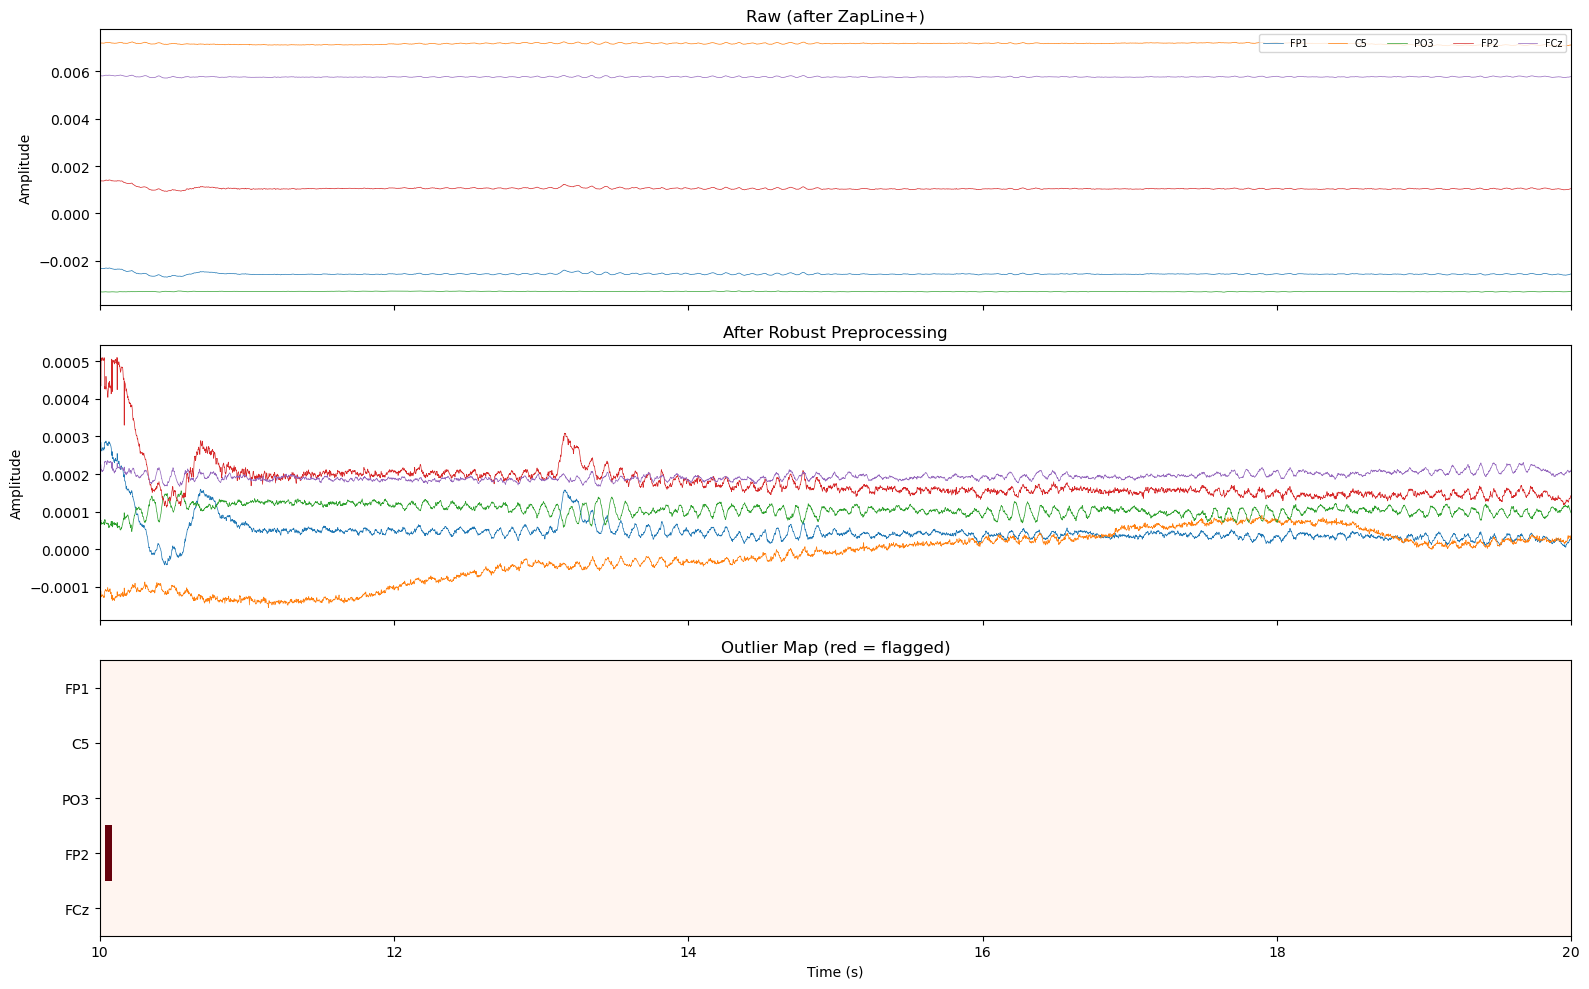

In [11]:
# ── Visualize before/after robust preprocessing ───────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)

# Select a 10-second window
t_start = 10  # seconds
t_end = 20
s_start = int(t_start * sfreq)
s_end = int(t_end * sfreq)
t_plot = np.arange(s_start, s_end) / sfreq

# Plot 5 channels
ch_show = [0, 5, 10, 15, 20]
ch_show = [c for c in ch_show if c < data_raw.shape[0]]

offsets = np.arange(len(ch_show)) * 50e-6  # spacing

ax = axes[0]
for i, ch in enumerate(ch_show):
    ax.plot(t_plot, data_raw[ch, s_start:s_end] + offsets[i],
            linewidth=0.5, label=raw.ch_names[ch])
ax.set_title("Raw (after ZapLine+)")
ax.set_ylabel("Amplitude")
ax.legend(fontsize=7, ncol=len(ch_show), loc="upper right")

ax = axes[1]
for i, ch in enumerate(ch_show):
    ax.plot(t_plot, data_robust[ch, s_start:s_end] + offsets[i],
            linewidth=0.5)
ax.set_title("After Robust Preprocessing")
ax.set_ylabel("Amplitude")

ax = axes[2]
# Weight matrix (outlier map)
w_show = weights[ch_show, s_start:s_end]
ax.imshow(1 - w_show, aspect="auto", cmap="Reds",
          extent=[t_start, t_end, len(ch_show)-0.5, -0.5],
          interpolation="none", vmin=0, vmax=1)
ax.set_yticks(range(len(ch_show)))
ax.set_yticklabels([raw.ch_names[ch] for ch in ch_show])
ax.set_title("Outlier Map (red = flagged)")
ax.set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

## 4. DSS for Evoked Response Enhancement

Following de Cheveigné & Parra (2014), §Stimulus-evoked activity:

> *The aim here is to improve SNR by finding the subspace that is most*
> *repeatable across trials. [...] C₀ was the covariance matrix of the raw data,*
> *and C₁ the covariance matrix of the data averaged over trials.*

The optimality criterion maximizes the power of the mean (evoked) divided
by total power. The first component has the **strongest possible mean effect**
relative to overall variability.

### Two-Stage Approach (de Cheveigné & Parra, 2014 §Two conditions)

> *JD was first applied to identify a signal subspace that favors*
> *reproducibility [...] In a second stage, JD was applied to a selected*
> *subset of components from the first stage.*

1. **Stage 1:** DSS with trial-average bias → find reproducible subspace
2. **Stage 2:** DSS on selected components with condition-contrast bias → find face-selective activity

In [12]:
# ── Test DSS on single subject (robustly preprocessed) ─────────────

# Apply robust preprocessing to raw object
raw_robust = raw.copy()
raw_robust._data = data_robust

# Light filtering (no aggressive high-pass — de Cheveigné advocates alternatives)
# We use a mild 0.1 Hz HPF + 30 Hz LPF as in Kessler et al. (2025)
raw_filt = raw_robust.filter(l_freq=0.1, h_freq=30.0, verbose=False)

# Epoch
TMIN, TMAX = -0.2, 0.8
BASELINE = (-0.2, 0.0)
REJECT = dict(eeg=150e-6)  # slightly more lenient since we already cleaned

FACE_RANGE = set(range(1, 41))
CAR_RANGE = set(range(41, 81))

events, event_id = mne.events_from_annotations(raw_filt, verbose=False)

face_id = {k: v for k, v in event_id.items()
           if v in FACE_RANGE or (k.isdigit() and int(k) in FACE_RANGE)}
car_id = {k: v for k, v in event_id.items()
          if v in CAR_RANGE or (k.isdigit() and int(k) in CAR_RANGE)}

epochs_face = mne.Epochs(raw_filt, events, face_id, tmin=TMIN, tmax=TMAX,
                         baseline=BASELINE, preload=True, reject=REJECT,
                         verbose=False)
epochs_car = mne.Epochs(raw_filt, events, car_id, tmin=TMIN, tmax=TMAX,
                        baseline=BASELINE, preload=True, reject=REJECT,
                        verbose=False)

print(f"Face epochs: {len(epochs_face)}, Car epochs: {len(epochs_car)}")

Face epochs: 87, Car epochs: 88


Stage 1 DSS eigenvalues (top 10): [0.1776 0.0623 0.0392 0.0335 0.0124 0.0099 0.0083 0.0075 0.0064 0.006 ]
Explained variance (top 16): 100.0%


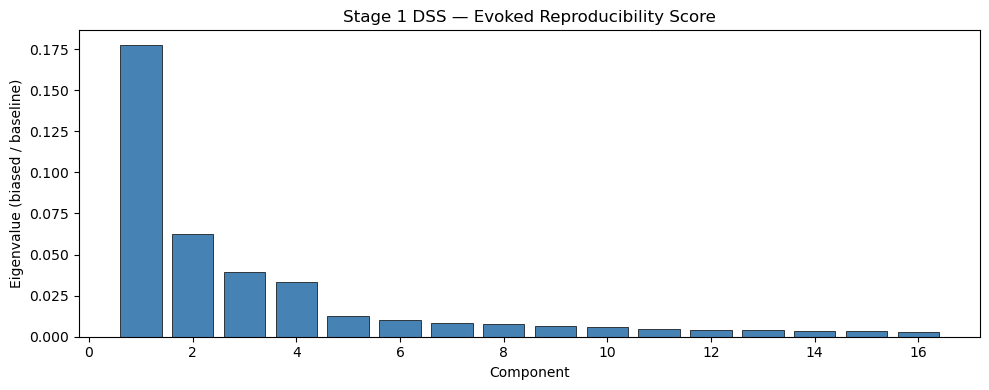

In [13]:
# ── Stage 1 DSS: Trial-average bias (evoked reproducibility) ──────
# de Cheveigné & Parra (2014), §Stimulus-evoked activity

data_face = epochs_face.get_data(copy=True)  # (n_f, n_ch, n_t)
data_car = epochs_car.get_data(copy=True)    # (n_c, n_ch, n_t)
data_all = np.concatenate([data_face, data_car], axis=0)

n_all, n_ch, n_t = data_all.shape

# C0: covariance of all data
data_2d = data_all.transpose(1, 0, 2).reshape(n_ch, -1)
C0 = compute_covariance(data_2d)

# C1: covariance of trial-averaged data (evoked)
avg_all = data_all.mean(axis=0)  # (n_ch, n_t)
avg_tiled = np.tile(avg_all, (1, n_all))
C1 = compute_covariance(avg_tiled)

# Compute Stage 1 DSS
N_DSS_STAGE1 = 16  # Keep top 16 reproducible components
result_s1 = compute_dss(C0, C1, n_components=N_DSS_STAGE1)

print(f"Stage 1 DSS eigenvalues (top 10): {result_s1.eigenvalues[:10].round(4)}")
print(f"Explained variance (top {N_DSS_STAGE1}): "
      f"{result_s1.eigenvalues.sum() / result_s1.eigenvalues.sum():.1%}")

# Eigenvalue bar plot
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, len(result_s1.eigenvalues)+1), result_s1.eigenvalues,
       color="steelblue", edgecolor="k", linewidth=0.5)
ax.set_xlabel("Component")
ax.set_ylabel("Eigenvalue (biased / baseline)")
ax.set_title("Stage 1 DSS — Evoked Reproducibility Score")
plt.tight_layout()
plt.show()

In [14]:
# ── Stage 2 DSS: Condition contrast in the reproducible subspace ──
# de Cheveigné & Parra (2014), §Two conditions, repeated trials:
#   "JD was first applied to isolate a subspace of component signals
#    that responded reproducibly to both stimuli (V and AV). [...]
#    In a second stage, JD was applied to a selected subset of
#    components from the first stage, using as C1 the covariance of
#    the difference between averages over trials for the V and AV
#    conditions."

# Project data into Stage 1 subspace
data_s1 = np.zeros((n_all, N_DSS_STAGE1, n_t))
for i in range(n_all):
    data_s1[i] = result_s1.filters @ data_all[i]  # (n_comp, n_t)

# Split back into face/car
n_face = data_face.shape[0]
data_s1_face = data_s1[:n_face]
data_s1_car = data_s1[n_face:]

# Stage 2: C0 = covariance of Stage 1 components
data_s1_2d = data_s1.transpose(1, 0, 2).reshape(N_DSS_STAGE1, -1)
C0_s2 = compute_covariance(data_s1_2d)

# Stage 2: C1 = covariance of condition difference
face_avg_s1 = data_s1_face.mean(axis=0)  # (n_comp, n_t)
car_avg_s1 = data_s1_car.mean(axis=0)
diff_avg_s1 = face_avg_s1 - car_avg_s1

diff_tiled_s1 = np.tile(diff_avg_s1, (1, n_all))
C1_s2 = compute_covariance(diff_tiled_s1)

N_DSS_STAGE2 = 6
result_s2 = compute_dss(C0_s2, C1_s2, n_components=N_DSS_STAGE2)

print(f"Stage 2 DSS eigenvalues: {result_s2.eigenvalues.round(4)}")

# Combined transform: sensor → Stage 1 → Stage 2
# W_combined = W_s2 @ W_s1
W_combined = result_s2.filters @ result_s1.filters  # (n_s2, n_ch)
M_combined = np.linalg.pinv(W_combined)  # (n_ch, n_s2)

print(f"Combined filters shape: {W_combined.shape}")
print(f"Combined mixing shape: {M_combined.shape}")

Stage 2 DSS eigenvalues: [0.0452 0.0359 0.0281 0.0241 0.0218 0.0195]
Combined filters shape: (6, 30)
Combined mixing shape: (30, 6)


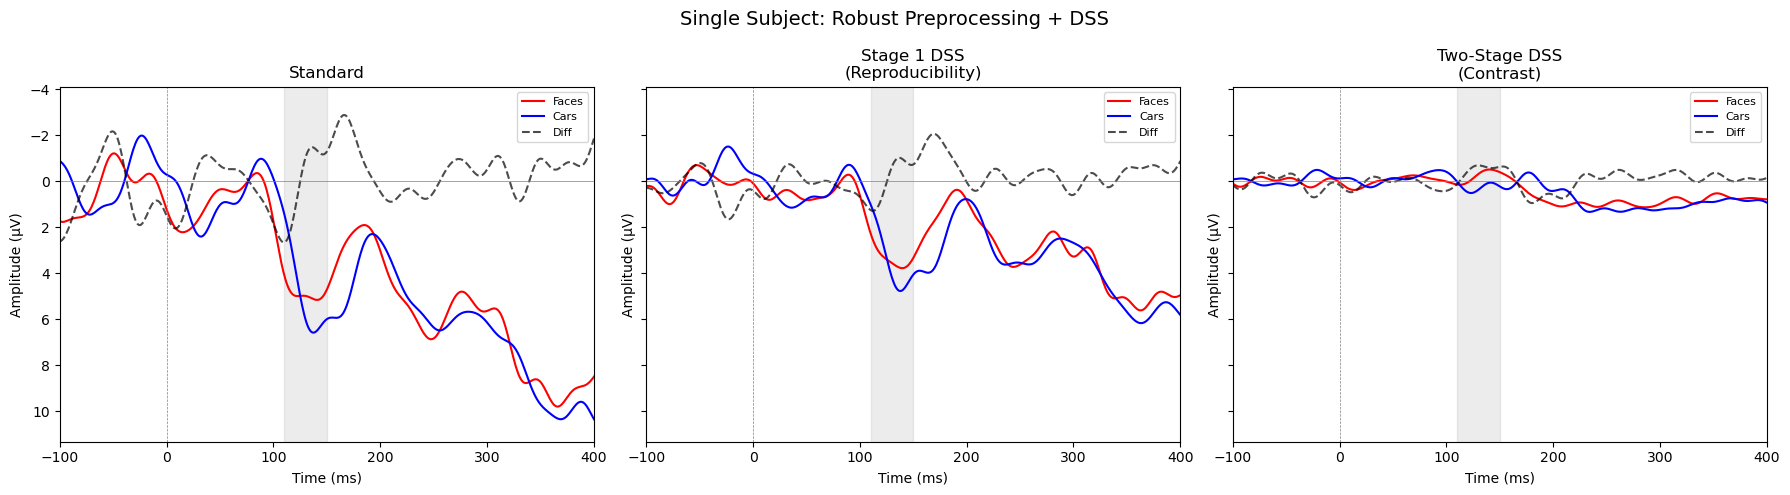

In [15]:
# ── Apply combined DSS and compare ────────────────────────────────
ROI_CHANNELS = ["PO7", "PO8"]
N170_WIN = (0.110, 0.150)

# Standard evoked (no DSS)
evoked_face_std = epochs_face.average()
evoked_car_std = epochs_car.average()

# DSS-denoised evoked (Stage 1 only — reproducibility)
def apply_dss_filters(data_in, filters, mixing):
    data_out = np.zeros_like(data_in)
    for i in range(data_in.shape[0]):
        sources = filters @ data_in[i]
        data_out[i] = mixing @ sources
    return data_out

# Stage 1 denoising (keep top 16 reproducible components)
data_face_s1 = apply_dss_filters(data_face, result_s1.filters, result_s1.mixing)
data_car_s1 = apply_dss_filters(data_car, result_s1.filters, result_s1.mixing)

# Two-stage denoising (top 6 condition-discriminative within top 16)
data_face_s2 = apply_dss_filters(data_face, W_combined, M_combined)
data_car_s2 = apply_dss_filters(data_car, W_combined, M_combined)

# Create evokeds
ep_face_s1 = epochs_face.copy(); ep_face_s1._data = data_face_s1
ep_car_s1 = epochs_car.copy(); ep_car_s1._data = data_car_s1
ep_face_s2 = epochs_face.copy(); ep_face_s2._data = data_face_s2
ep_car_s2 = epochs_car.copy(); ep_car_s2._data = data_car_s2

evoked_face_s1 = ep_face_s1.average()
evoked_car_s1 = ep_car_s1.average()
evoked_face_s2 = ep_face_s2.average()
evoked_car_s2 = ep_car_s2.average()

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

times_ms = epochs_face.times * 1000
ch_names = epochs_face.ch_names
roi_idx = [ch_names.index(ch) for ch in ROI_CHANNELS if ch in ch_names]

for ax, ev_f, ev_c, title in zip(
    axes,
    [evoked_face_std, evoked_face_s1, evoked_face_s2],
    [evoked_car_std, evoked_car_s1, evoked_car_s2],
    ["Standard", "Stage 1 DSS\n(Reproducibility)",
     "Two-Stage DSS\n(Contrast)"],
):
    face_d = ev_f.data[roi_idx].mean(axis=0) * 1e6
    car_d = ev_c.data[roi_idx].mean(axis=0) * 1e6
    diff_d = face_d - car_d

    ax.plot(times_ms, face_d, "r-", linewidth=1.5, label="Faces")
    ax.plot(times_ms, car_d, "b-", linewidth=1.5, label="Cars")
    ax.plot(times_ms, diff_d, "k--", linewidth=1.5, alpha=0.7, label="Diff")
    ax.axvspan(N170_WIN[0]*1000, N170_WIN[1]*1000, alpha=0.15, color="gray")
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.axvline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Amplitude (µV)")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.set_xlim(-100, 400)
    ax.invert_yaxis()

fig.suptitle("Single Subject: Robust Preprocessing + DSS", fontsize=14)
plt.tight_layout()
plt.show()

## 5. Multi-Subject Processing

We now process all 40 subjects through **four pipelines** and compare:

| Pipeline | Preprocessing | DSS |
|----------|--------------|-----|
| **A. Standard** | Filter + Avg ref | None |
| **B. Robust Only** | Robust detrend + outlier + inpaint + robust reref | None |
| **C. Robust + Stage 1 DSS** | Robust preprocessing | Trial-average DSS (top K) |
| **D. Robust + Two-Stage DSS** | Robust preprocessing | Stage 1 → Stage 2 (contrast) |

### Metrics
- **N170 Peak Amplitude** (PO7/PO8, 110–150 ms)
- **Face–Car Difference** amplitude
- **Evoked SNR** (signal power / residual noise power)
- **SME** (Standardized Measurement Error)
- **GFP** (Global Field Power) in N170 window

In [16]:
# ══════════════════════════════════════════════════════════════════════
# Configuration
# ══════════════════════════════════════════════════════════════════════
LINE_FREQ = 60.0
FILT_LOW, FILT_HIGH = 0.1, 30.0
TMIN, TMAX = -0.2, 0.8
BASELINE = (-0.2, 0.0)
REJECT = dict(eeg=150e-6)
N170_WIN = (0.110, 0.150)
ROI_CHANNELS = ["PO7", "PO8"]
FACE_RANGE = set(range(1, 41))
CAR_RANGE = set(range(41, 81))
EOG_CHANNELS = ["HEOG_left", "HEOG_right", "VEOG_lower"]

# DSS parameters
N_DSS_S1 = 16    # Stage 1: reproducible subspace dimension
N_DSS_S2 = 6     # Stage 2: contrast components

# Robust preprocessing parameters (de Cheveigné & Arzounian, 2018)
DETREND_ORDER = 5
DETREND_THRESH = 3.0
OUTLIER_ITER = 5
OUTLIER_THRESH = 3.0

montage = mne.channels.make_standard_montage("standard_1005")

print("Configuration set.")

Configuration set.


In [30]:
# ══════════════════════════════════════════════════════════════════════
# Metric computation helpers
# ══════════════════════════════════════════════════════════════════════

def compute_metrics(ev_face, ev_car, ep_face, ep_car, label):
    """Compute ERP metrics at ROI channels (sensor-space pipelines)."""
    times = ev_face.times
    ch_names = ev_face.ch_names
    roi_idx = [ch_names.index(ch) for ch in ROI_CHANNELS if ch in ch_names]
    if not roi_idx:
        raise ValueError("ROI channels not found")

    t_idx = np.where((times >= N170_WIN[0]) & (times <= N170_WIN[1]))[0]
    metrics = {}

    face_roi = ev_face.data[roi_idx][:, t_idx].mean(axis=0)
    car_roi = ev_car.data[roi_idx][:, t_idx].mean(axis=0)

    # Peak amplitudes (µV)
    metrics[f"face_amp_{label}"] = face_roi.min() * 1e6
    metrics[f"car_amp_{label}"] = car_roi.min() * 1e6
    metrics[f"diff_amp_{label}"] = metrics[f"face_amp_{label}"] - metrics[f"car_amp_{label}"]

    # Peak latencies (ms)
    metrics[f"face_lat_{label}"] = times[t_idx[np.argmin(face_roi)]] * 1000
    metrics[f"car_lat_{label}"] = times[t_idx[np.argmin(car_roi)]] * 1000

    # SNR
    face_ev_roi = ev_face.data[roi_idx]
    car_ev_roi = ev_car.data[roi_idx]
    signal_power = np.mean(face_ev_roi[:, t_idx]**2 + car_ev_roi[:, t_idx]**2)

    face_ep = ep_face.get_data(copy=True)[:, roi_idx, :]
    car_ep = ep_car.get_data(copy=True)[:, roi_idx, :]
    res_f = face_ep - face_ev_roi[np.newaxis, :, :]
    res_c = car_ep - car_ev_roi[np.newaxis, :, :]
    noise_power = (np.mean(res_f[:, :, t_idx]**2) + np.mean(res_c[:, :, t_idx]**2)) / 2
    metrics[f"snr_{label}"] = 10 * np.log10(signal_power / max(noise_power, 1e-30))

    # SME
    n_f = face_ep.shape[0]
    n_c = car_ep.shape[0]
    face_sme = np.std(face_ep[:, :, t_idx].mean(axis=2), axis=0, ddof=1) / np.sqrt(n_f)
    car_sme = np.std(car_ep[:, :, t_idx].mean(axis=2), axis=0, ddof=1) / np.sqrt(n_c)
    metrics[f"sme_{label}"] = np.sqrt(face_sme.mean()**2 + car_sme.mean()**2) * 1e6

    # Cohen's d: face vs car single-trial effect size in N170 window at ROI
    face_trial_amp = face_ep[:, :, t_idx].mean(axis=(1, 2))
    car_trial_amp = car_ep[:, :, t_idx].mean(axis=(1, 2))
    pooled_std = np.sqrt((np.var(face_trial_amp, ddof=1) +
                          np.var(car_trial_amp, ddof=1)) / 2)
    metrics[f"cohens_d_{label}"] = ((face_trial_amp.mean() - car_trial_amp.mean())
                                    / max(pooled_std, 1e-30))

    # GFP (sensor space only — kept for reference)
    diff_evoked = ev_face.data - ev_car.data
    metrics[f"gfp_{label}"] = np.std(diff_evoked[:, t_idx], axis=0).mean() * 1e6

    return metrics


def compute_metrics_dss(comp_face_all, comp_car_all, times, label,
                        mixing, roi_idx):
    """Compute ERP metrics on DSS component 1 (virtual electrode).

    Amplitudes are scaled to equivalent µV at ROI channels using the
    mixing matrix, making them directly comparable with sensor-space metrics.

    Parameters
    ----------
    comp_face_all : (n_trials, n_comp, n_times)
    comp_car_all  : (n_trials, n_comp, n_times)
    times         : (n_times,) seconds
    label         : str  — pipeline label
    mixing        : (n_ch, n_comp) — back-projection matrix
    roi_idx       : list of int — ROI channel indices
    """
    t_idx = np.where((times >= N170_WIN[0]) & (times <= N170_WIN[1]))[0]

    # Scale component 1 to equivalent µV at ROI
    # mixing[ch, 0] * comp1_value = channel contribution in Volts
    roi_scale = mixing[roi_idx, 0].mean() * 1e6  # → µV

    c1_f = comp_face_all[:, 0, :] * roi_scale   # (n_trials, n_times)
    c1_c = comp_car_all[:, 0, :]  * roi_scale

    ev_f = c1_f.mean(axis=0)   # evoked
    ev_c = c1_c.mean(axis=0)

    # Sign convention: N170 should be negative in the window
    if (ev_f[t_idx].mean() + ev_c[t_idx].mean()) > 0:
        c1_f, c1_c = -c1_f, -c1_c
        ev_f, ev_c = -ev_f, -ev_c

    metrics = {}

    face_win = ev_f[t_idx]
    car_win  = ev_c[t_idx]

    # Peak amplitudes (equivalent µV at ROI)
    metrics[f"face_amp_{label}"] = face_win.min()
    metrics[f"car_amp_{label}"] = car_win.min()
    metrics[f"diff_amp_{label}"] = metrics[f"face_amp_{label}"] - metrics[f"car_amp_{label}"]

    # Peak latencies (ms)
    metrics[f"face_lat_{label}"] = times[t_idx[np.argmin(face_win)]] * 1000
    metrics[f"car_lat_{label}"] = times[t_idx[np.argmin(car_win)]] * 1000

    # SNR (dB)
    signal_power = np.mean(face_win**2 + car_win**2)
    res_f = c1_f - ev_f[np.newaxis, :]
    res_c = c1_c - ev_c[np.newaxis, :]
    noise_power = (np.mean(res_f[:, t_idx]**2) + np.mean(res_c[:, t_idx]**2)) / 2
    metrics[f"snr_{label}"] = 10 * np.log10(signal_power / max(noise_power, 1e-30))

    # SME (µV)
    n_f, n_c_ = c1_f.shape[0], c1_c.shape[0]
    face_sme = np.std(c1_f[:, t_idx].mean(axis=1), ddof=1) / np.sqrt(n_f)
    car_sme  = np.std(c1_c[:, t_idx].mean(axis=1), ddof=1) / np.sqrt(n_c_)
    metrics[f"sme_{label}"] = np.sqrt(face_sme**2 + car_sme**2)

    # Cohen's d — dimensionless, directly comparable across representations
    face_trial = c1_f[:, t_idx].mean(axis=1)
    car_trial  = c1_c[:, t_idx].mean(axis=1)
    pooled_std = np.sqrt((np.var(face_trial, ddof=1) +
                          np.var(car_trial, ddof=1)) / 2)
    metrics[f"cohens_d_{label}"] = ((face_trial.mean() - car_trial.mean())
                                    / max(pooled_std, 1e-30))

    # GFP analogue: peak |face − car| on component 1 (µV equivalent)
    diff = ev_f - ev_c
    metrics[f"gfp_{label}"] = np.abs(diff[t_idx]).max()

    return metrics


print("✓ compute_metrics() + compute_metrics_dss() defined")

✓ compute_metrics() + compute_metrics_dss() defined


In [31]:
# ══════════════════════════════════════════════════════════════════════
# Main processing function — 4 pipelines per subject
# ══════════════════════════════════════════════════════════════════════

def process_subject_full(eeg_file, return_evokeds=False):
    """Process one subject through all 4 pipelines.

    A. Standard:         Filter + avg ref + epoch
    B. Robust:           Robust preproc + filter + epoch
    C. Robust + S1 DSS:  B + Stage 1 DSS (trial-average)
    D. Robust + S1+S2:   B + Two-stage DSS (reproducibility → contrast)

    DSS metrics are computed in component space (DSS-1 virtual electrode),
    scaled to equivalent µV at ROI via the mixing matrix.
    Back-projected evokeds are still stored for topography visualization.
    """
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        raw = mne.io.read_raw_eeglab(eeg_file, preload=True, verbose=False)
    raw.set_montage(montage, on_missing="ignore")
    sfreq = raw.info["sfreq"]

    # ── ZapLine+ (common to all pipelines) ────────────────────────
    zap = ZapLine(sfreq=sfreq, line_freq=LINE_FREQ, adaptive=True)
    raw._data = zap.fit_transform(raw.get_data())

    # Drop EOG
    eog = [ch for ch in EOG_CHANNELS if ch in raw.ch_names]
    if eog:
        raw.drop_channels(eog)

    # ══ Pipeline A: Standard ══════════════════════════════════════
    raw_std = raw.copy()
    raw_std.filter(FILT_LOW, FILT_HIGH, verbose=False)
    raw_std.set_eeg_reference("average", projection=True, verbose=False)
    raw_std.apply_proj(verbose=False)

    # ══ Pipeline B: Robust preprocessing ══════════════════════════
    data_raw = raw.get_data().copy()
    data_robust, weights, pp_info = robust_preprocess(
        data_raw, detrend_order=DETREND_ORDER, detrend_thresh=DETREND_THRESH,
        outlier_iter=OUTLIER_ITER, outlier_thresh=OUTLIER_THRESH
    )
    raw_rob = raw.copy()
    raw_rob._data = data_robust
    raw_rob.filter(FILT_LOW, FILT_HIGH, verbose=False)
    raw_rob.set_eeg_reference("average", projection=True, verbose=False)
    raw_rob.apply_proj(verbose=False)

    # ── Create epochs for both pipelines ──────────────────────────
    all_metrics = {}
    evokeds_out = {}

    for pipe_label, raw_pipe in [("std", raw_std), ("rob", raw_rob)]:
        events, event_id = mne.events_from_annotations(raw_pipe, verbose=False)

        face_id = {k: v for k, v in event_id.items()
                   if v in FACE_RANGE or (k.isdigit() and int(k) in FACE_RANGE)}
        car_id = {k: v for k, v in event_id.items()
                  if v in CAR_RANGE or (k.isdigit() and int(k) in CAR_RANGE)}

        if not face_id or not car_id:
            raise ValueError("Missing events")

        ep_face = mne.Epochs(raw_pipe, events, face_id, tmin=TMIN, tmax=TMAX,
                             baseline=BASELINE, preload=True, reject=REJECT,
                             verbose=False)
        ep_car = mne.Epochs(raw_pipe, events, car_id, tmin=TMIN, tmax=TMAX,
                            baseline=BASELINE, preload=True, reject=REJECT,
                            verbose=False)

        if len(ep_face) < 10 or len(ep_car) < 10:
            raise ValueError(f"Too few epochs: face={len(ep_face)}, car={len(ep_car)}")

        ev_face = ep_face.average()
        ev_car = ep_car.average()

        all_metrics.update(compute_metrics(ev_face, ev_car, ep_face, ep_car, pipe_label))
        all_metrics[f"n_face_{pipe_label}"] = len(ep_face)
        all_metrics[f"n_car_{pipe_label}"] = len(ep_car)

        if return_evokeds:
            evokeds_out[f"face_{pipe_label}"] = ev_face
            evokeds_out[f"car_{pipe_label}"] = ev_car

        # ── DSS (only on robust-preprocessed data, pipe_label="rob") ──
        if pipe_label == "rob":
            d_face = ep_face.get_data(copy=True)
            d_car = ep_car.get_data(copy=True)
            d_all = np.concatenate([d_face, d_car], axis=0)
            n_all, n_ch, n_t = d_all.shape

            # ROI indices for DSS amplitude scaling
            roi_idx = [ep_face.ch_names.index(ch) for ch in ROI_CHANNELS
                       if ch in ep_face.ch_names]

            # Baseline covariance
            d2 = d_all.transpose(1, 0, 2).reshape(n_ch, -1)
            cov0 = compute_covariance(d2)

            # ── Stage 1: trial-average ────────────────────────────
            avg = d_all.mean(axis=0)
            avg_t = np.tile(avg, (1, n_all))
            cov1 = compute_covariance(avg_t)

            res_s1 = compute_dss(cov0, cov1, n_components=N_DSS_S1)

            # Back-project to sensor space (for topography / waveform viz)
            d_face_s1 = apply_dss_filters(d_face, res_s1.filters, res_s1.mixing)
            d_car_s1 = apply_dss_filters(d_car, res_s1.filters, res_s1.mixing)

            ep_f_s1 = ep_face.copy(); ep_f_s1._data = d_face_s1
            ep_c_s1 = ep_car.copy(); ep_c_s1._data = d_car_s1
            ev_f_s1 = ep_f_s1.average()
            ev_c_s1 = ep_c_s1.average()

            # ── Metrics in component space (DSS-1 virtual electrode) ──
            comp_f_s1 = np.einsum('jk,ikt->ijt', res_s1.filters, d_face)
            comp_c_s1 = np.einsum('jk,ikt->ijt', res_s1.filters, d_car)
            all_metrics.update(compute_metrics_dss(
                comp_f_s1, comp_c_s1, ep_face.times, "s1",
                mixing=res_s1.mixing, roi_idx=roi_idx))
            all_metrics["dss_ev1_s1"] = res_s1.eigenvalues[0]

            if return_evokeds:
                evokeds_out["face_s1"] = ev_f_s1
                evokeds_out["car_s1"] = ev_c_s1

            # ── Stage 2: condition contrast ───────────────────────
            # Project into Stage 1 subspace
            d_s1 = np.zeros((n_all, N_DSS_S1, n_t))
            for i in range(n_all):
                d_s1[i] = res_s1.filters @ d_all[i]

            n_f = d_face.shape[0]
            d_s1_f = d_s1[:n_f]
            d_s1_c = d_s1[n_f:]

            c0_s2 = compute_covariance(d_s1.transpose(1, 0, 2).reshape(N_DSS_S1, -1))
            diff_s1 = d_s1_f.mean(axis=0) - d_s1_c.mean(axis=0)
            diff_t_s1 = np.tile(diff_s1, (1, n_all))
            c1_s2 = compute_covariance(diff_t_s1)

            res_s2 = compute_dss(c0_s2, c1_s2, n_components=N_DSS_S2)

            W_comb = res_s2.filters @ res_s1.filters
            M_comb = np.linalg.pinv(W_comb)

            # Back-project to sensor space (visualization only)
            d_face_s2 = apply_dss_filters(d_face, W_comb, M_comb)
            d_car_s2 = apply_dss_filters(d_car, W_comb, M_comb)

            ep_f_s2 = ep_face.copy(); ep_f_s2._data = d_face_s2
            ep_c_s2 = ep_car.copy(); ep_c_s2._data = d_car_s2
            ev_f_s2 = ep_f_s2.average()
            ev_c_s2 = ep_c_s2.average()

            # ── Metrics in component space (combined DSS-1) ──────
            comp_f_s2 = np.einsum('jk,ikt->ijt', W_comb, d_face)
            comp_c_s2 = np.einsum('jk,ikt->ijt', W_comb, d_car)
            all_metrics.update(compute_metrics_dss(
                comp_f_s2, comp_c_s2, ep_face.times, "s2",
                mixing=M_comb, roi_idx=roi_idx))
            all_metrics["dss_ev1_s2"] = res_s2.eigenvalues[0]

            if return_evokeds:
                evokeds_out["face_s2"] = ev_f_s2
                evokeds_out["car_s2"] = ev_c_s2

    # Preprocessing stats
    all_metrics["pct_outlier"] = pp_info["pct_outlier_total"]

    if return_evokeds:
        all_metrics["_evokeds"] = evokeds_out

    return all_metrics


print("✓ process_subject_full() defined — DSS metrics in component space")

✓ process_subject_full() defined — DSS metrics in component space


In [42]:
# ══════════════════════════════════════════════════════════════════════
# Process all subjects
# ══════════════════════════════════════════════════════════════════════
results = []
all_evokeds = defaultdict(list)

print(f"Processing {len(n170_files)} subjects through 4 pipelines...\n")
t0 = _time.time()

for idx, eeg_file in enumerate(n170_files):
    sub_id = eeg_file.parent.parent.name
    try:
        res = process_subject_full(eeg_file, return_evokeds=True)
        res["subject"] = sub_id

        # Collect evokeds
        evokeds = res.pop("_evokeds")
        for key, ev in evokeds.items():
            all_evokeds[key].append(ev)

        results.append(res)
        print(f"  [{idx+1:2d}/40] {sub_id}: OK  "
              f"(outlier={res['pct_outlier']:.1f}%, "
              f"SNR std={res['snr_std']:.1f}, rob={res['snr_rob']:.1f}, "
              f"s1={res['snr_s1']:.1f}, s2={res['snr_s2']:.1f} dB)")

    except Exception as e:
        print(f"  [{idx+1:2d}/40] {sub_id}: FAILED — {e}")

elapsed = _time.time() - t0
df = pd.DataFrame(results).set_index("subject")
print(f"\n✓ Processed {len(df)}/40 subjects in {elapsed:.0f}s")

Processing 40 subjects through 4 pipelines...

  [ 1/40] sub-001: OK  (outlier=6.1%, SNR std=-4.1, rob=-3.8, s1=-3.0, s2=-13.9 dB)
  [ 2/40] sub-002: OK  (outlier=4.7%, SNR std=0.4, rob=0.3, s1=2.4, s2=-15.6 dB)
  [ 3/40] sub-003: OK  (outlier=6.0%, SNR std=4.7, rob=3.4, s1=7.8, s2=-1.5 dB)
  [ 4/40] sub-004: OK  (outlier=4.5%, SNR std=-6.1, rob=-6.9, s1=4.7, s2=-3.3 dB)
  [ 5/40] sub-005: OK  (outlier=9.9%, SNR std=5.0, rob=4.5, s1=7.3, s2=0.4 dB)
  [ 6/40] sub-006: OK  (outlier=4.9%, SNR std=-2.7, rob=-2.5, s1=3.0, s2=-11.2 dB)
  [ 7/40] sub-007: OK  (outlier=2.6%, SNR std=0.5, rob=-0.9, s1=-0.8, s2=-3.7 dB)
  [ 8/40] sub-008: OK  (outlier=3.9%, SNR std=-2.0, rob=-1.8, s1=-1.5, s2=-4.2 dB)
  [ 9/40] sub-009: OK  (outlier=4.1%, SNR std=2.5, rob=-0.7, s1=2.7, s2=-7.8 dB)
  [10/40] sub-010: OK  (outlier=1.7%, SNR std=-5.3, rob=-5.3, s1=-4.9, s2=-9.2 dB)
  [11/40] sub-011: OK  (outlier=3.0%, SNR std=6.9, rob=5.0, s1=8.8, s2=-5.8 dB)
  [12/40] sub-012: OK  (outlier=2.8%, SNR std=0.9, rob=

In [43]:
# ── Summary Table ─────────────────────────────────────────────────
summary_cols = [
    ("diff_amp", "Face–Car Amp (µV)"),
    ("snr", "Evoked SNR (dB)"),
    ("sme", "SME (µV)"),
    ("cohens_d", "Cohen's d (Face–Car)"),
]

pipe_labels = ["std", "rob", "s1", "s2"]
pipe_names = ["Standard", "Robust", "Robust+S1", "Robust+S1+S2"]

print(f"\n{'Metric':<26s}", end="")
for name in pipe_names:
    print(f"{name:>14s}", end="")
print()
print("─" * 82)

for col, label in summary_cols:
    print(f"{label:<26s}", end="")
    for pl in pipe_labels:
        val = df[f"{col}_{pl}"].mean()
        print(f"{val:>14.3f}", end="")
    print()

print("\nNote: S1/S2 amplitudes are DSS component-1 values scaled to")
print("      equivalent µV at ROI via the mixing matrix.")


Metric                          Standard        Robust     Robust+S1  Robust+S1+S2
──────────────────────────────────────────────────────────────────────────────────
Face–Car Amp (µV)                 -1.084        -1.120         0.167         0.001
Evoked SNR (dB)                    0.374        -0.611         2.555        -6.286
SME (µV)                           1.186         1.290         0.380         0.082
Cohen's d (Face–Car)              -0.137        -0.131         0.104         0.081

Note: S1/S2 amplitudes are DSS component-1 values scaled to
      equivalent µV at ROI via the mixing matrix.


## 6. Statistical Tests

Paired comparisons across all subjects.

| Test | Purpose |
|------|---------|
| Paired t-test | Parametric comparison |
| Wilcoxon signed-rank | Non-parametric alternative |
| Cohen's d | Effect size |
| BF₁₀ | Bayesian evidence |

In [44]:
# ── Statistical helpers ────────────────────────────────────────────

def cohens_d_paired(x, y):
    diff = x - y
    return diff.mean() / diff.std(ddof=1)

def bf10_paired(x, y):
    """BF₁₀ via BIC approximation (Wagenmakers 2007)."""
    n = len(x)
    t_stat = stats.ttest_rel(x, y).statistic
    bf01 = np.sqrt(n) * (1.0 + t_stat**2 / (n - 1)) ** (-n / 2.0)
    return 1.0 / max(bf01, 1e-300)


def run_paired_tests(df, col_a, col_b, label, higher_is_better=True):
    x = df[col_a].values
    y = df[col_b].values
    diff = y - x
    n = len(x)

    t_stat, t_p = stats.ttest_rel(y, x)
    w_stat, w_p = stats.wilcoxon(x, y)
    d = cohens_d_paired(y, x)
    bf = bf10_paired(x, y)

    direction = "B > A" if diff.mean() > 0 else "B < A"
    sig = "***" if t_p < 0.001 else "**" if t_p < 0.01 else "*" if t_p < 0.05 else "n.s."

    print(f"  {label:<35s} Δ={diff.mean():+.3f}  t={t_stat:+.2f}  "
          f"p={t_p:.2e} {sig}  d={d:+.2f}  BF₁₀={bf:.1f}")

    return {"metric": label, "a_mean": x.mean(), "b_mean": y.mean(),
            "diff": diff.mean(), "t": t_stat, "p": t_p, "d": d, "bf10": bf}


# ── Pairwise comparisons ──────────────────────────────────────────
comparisons_to_run = [
    # (col_metric, label, higher_is_better)
    ("diff_amp", "Face–Car Amp (µV)", False),
    ("snr", "Evoked SNR (dB)", True),
    ("sme", "SME (µV)", False),
    ("cohens_d", "Cohen's d (Face–Car)", True),
]

# Compare Standard vs Robust
print("\n" + "=" * 80)
print("  STANDARD vs ROBUST PREPROCESSING")
print("=" * 80)
for col, label, hib in comparisons_to_run:
    run_paired_tests(df, f"{col}_std", f"{col}_rob", label, hib)

# Compare Standard vs Robust+S1
print("\n" + "=" * 80)
print("  STANDARD vs ROBUST + STAGE 1 DSS")
print("=" * 80)
for col, label, hib in comparisons_to_run:
    run_paired_tests(df, f"{col}_std", f"{col}_s1", label, hib)

# Compare Standard vs Robust+S1+S2
print("\n" + "=" * 80)
print("  STANDARD vs ROBUST + TWO-STAGE DSS")
print("=" * 80)
for col, label, hib in comparisons_to_run:
    run_paired_tests(df, f"{col}_std", f"{col}_s2", label, hib)

# Compare Robust vs Robust+S1
print("\n" + "=" * 80)
print("  ROBUST vs ROBUST + STAGE 1 DSS")
print("=" * 80)
for col, label, hib in comparisons_to_run:
    run_paired_tests(df, f"{col}_rob", f"{col}_s1", label, hib)


  STANDARD vs ROBUST PREPROCESSING
  Face–Car Amp (µV)                   Δ=-0.036  t=-0.44  p=6.65e-01 n.s.  d=-0.07  BF₁₀=0.2
  Evoked SNR (dB)                     Δ=-0.986  t=-7.03  p=2.98e-08 ***  d=-1.16  BF₁₀=1448525.4
  SME (µV)                            Δ=+0.104  t=+4.51  p=6.55e-05 ***  d=+0.74  BF₁₀=661.5
  Cohen's d (Face–Car)                Δ=+0.006  t=+0.47  p=6.40e-01 n.s.  d=+0.08  BF₁₀=0.2

  STANDARD vs ROBUST + STAGE 1 DSS
  Face–Car Amp (µV)                   Δ=+1.251  t=+3.55  p=1.10e-03 **  d=+0.58  BF₁₀=42.2
  Evoked SNR (dB)                     Δ=+2.181  t=+4.57  p=5.50e-05 ***  d=+0.75  BF₁₀=785.4
  SME (µV)                            Δ=-0.807  t=-9.76  p=1.17e-11 ***  d=-1.61  BF₁₀=4110596954.3
  Cohen's d (Face–Car)                Δ=+0.241  t=+3.95  p=3.47e-04 ***  d=+0.65  BF₁₀=129.2

  STANDARD vs ROBUST + TWO-STAGE DSS
  Face–Car Amp (µV)                   Δ=+1.085  t=+3.48  p=1.35e-03 **  d=+0.57  BF₁₀=34.7
  Evoked SNR (dB)                     Δ=-6.661  

## 7. Visualizations

Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
Identifying common channels ...
Identifying common channels ...


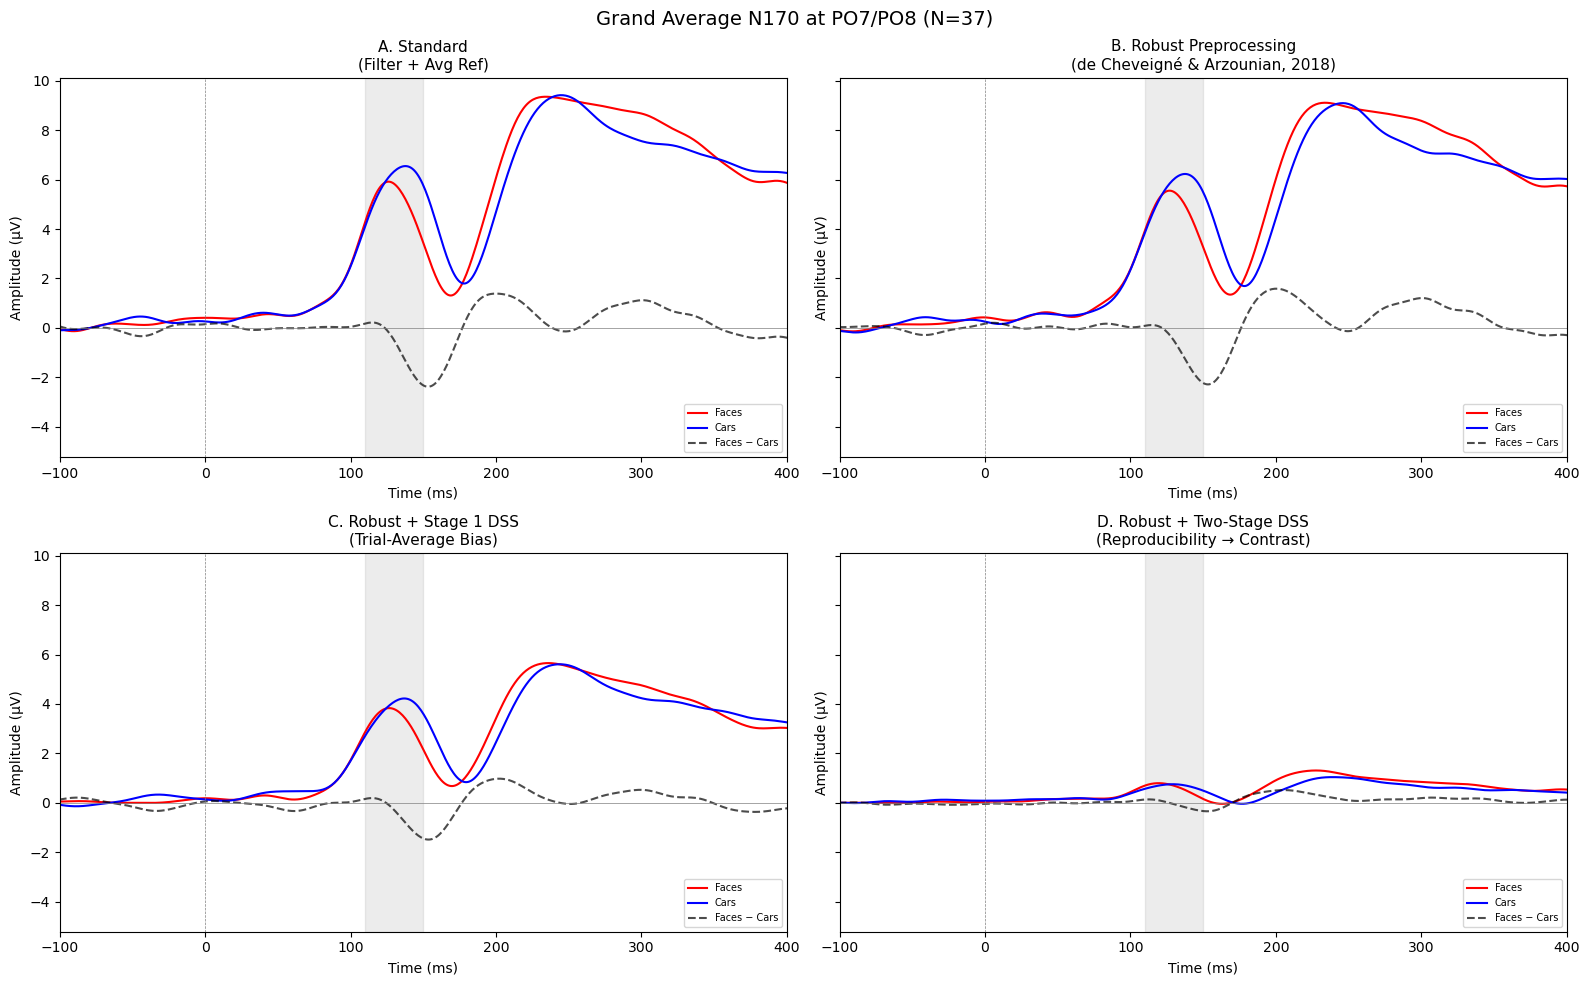

In [45]:
# ── Figure 1: Grand Average ERP — Four Pipelines ──────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharey=True)

# Compute grand averages
ga = {}
for key in all_evokeds:
    if len(all_evokeds[key]) > 0:
        ga[key] = mne.grand_average(all_evokeds[key])

times_ms = ga["face_std"].times * 1000
ch_names_ga = ga["face_std"].ch_names
roi_idx_ga = [ch_names_ga.index(ch) for ch in ROI_CHANNELS if ch in ch_names_ga]

panels = [
    ("std", "A. Standard\n(Filter + Avg Ref)"),
    ("rob", "B. Robust Preprocessing\n(de Cheveigné & Arzounian, 2018)"),
    ("s1", "C. Robust + Stage 1 DSS\n(Trial-Average Bias)"),
    ("s2", "D. Robust + Two-Stage DSS\n(Reproducibility → Contrast)"),
]

for ax, (pl, title) in zip(axes.flat, panels):
    fk, ck = f"face_{pl}", f"car_{pl}"
    if fk not in ga or ck not in ga:
        ax.set_visible(False)
        continue

    face_d = ga[fk].data[roi_idx_ga].mean(axis=0) * 1e6
    car_d = ga[ck].data[roi_idx_ga].mean(axis=0) * 1e6
    diff_d = face_d - car_d

    ax.plot(times_ms, face_d, "r-", linewidth=1.5, label="Faces")
    ax.plot(times_ms, car_d, "b-", linewidth=1.5, label="Cars")
    ax.plot(times_ms, diff_d, "k--", linewidth=1.5, alpha=0.7, label="Faces − Cars")
    ax.axvspan(N170_WIN[0]*1000, N170_WIN[1]*1000, alpha=0.15, color="gray")
    ax.axhline(0, color="gray", linewidth=0.5)
    ax.axvline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Amplitude (µV)")
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=7, loc="lower right")
    ax.set_xlim(-100, 400)
    ax.invert_yaxis()

fig.suptitle(f"Grand Average N170 at {'/'.join(ROI_CHANNELS)} (N={len(df)})",
             fontsize=14)
plt.tight_layout()
plt.savefig("fig1_robust_dss_grand_average.png", dpi=150, bbox_inches="tight")
plt.show()

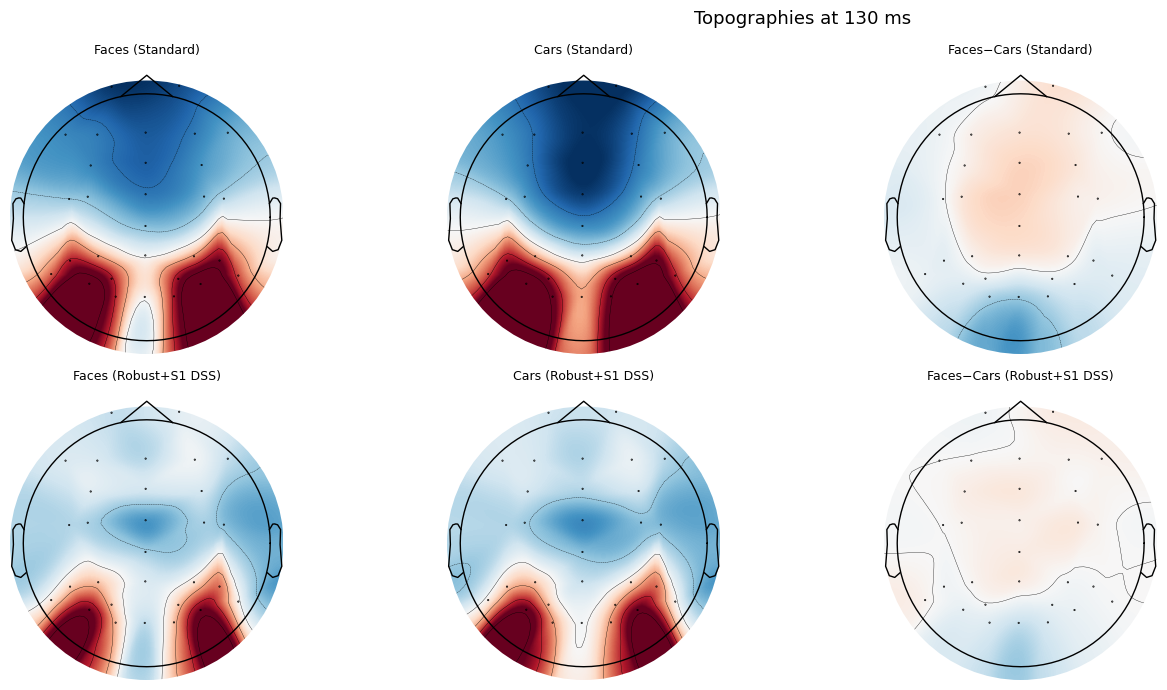

In [46]:
# ── Figure 2: Topographies at N170 peak ──────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 7))

t_peak = 0.130  # 130 ms
rename_map = {"FP1": "Fp1", "FP2": "Fp2"}
vlim = (-4, 4)

for row, (pl, pipe_name) in enumerate([
    ("std", "Standard"), ("s1", "Robust+S1 DSS")
]):
    for col, (cond_key, cond_name) in enumerate([
        (f"face_{pl}", "Faces"), (f"car_{pl}", "Cars"),
    ]):
        ax = axes[row, col]
        if cond_key in ga:
            ev = ga[cond_key].copy()
            renames = {k: v for k, v in rename_map.items() if k in ev.ch_names}
            if renames:
                ev.rename_channels(renames)
            ev.set_montage(montage, on_missing="ignore")
            ev.plot_topomap(times=[t_peak], axes=ax, show=False,
                           vlim=vlim, colorbar=False, time_unit="s")
        ax.set_title(f"{cond_name} ({pipe_name})", fontsize=9)

    # Difference topography
    fk, ck = f"face_{pl}", f"car_{pl}"
    if fk in ga and ck in ga:
        ax_diff = axes[row, 2]
        diff_ev = mne.combine_evoked([ga[fk], ga[ck]], weights=[1, -1])
        renames = {k: v for k, v in rename_map.items() if k in diff_ev.ch_names}
        if renames:
            diff_ev.rename_channels(renames)
        diff_ev.set_montage(montage, on_missing="ignore")
        diff_ev.plot_topomap(times=[t_peak], axes=ax_diff, show=False,
                            vlim=vlim, colorbar=False, time_unit="s")
        ax_diff.set_title(f"Faces−Cars ({pipe_name})", fontsize=9)

    axes[row, 3].set_visible(False)

fig.suptitle(f"Topographies at {t_peak*1000:.0f} ms", fontsize=13)
plt.tight_layout()
plt.savefig("fig2_robust_dss_topographies.png", dpi=150, bbox_inches="tight")
plt.show()

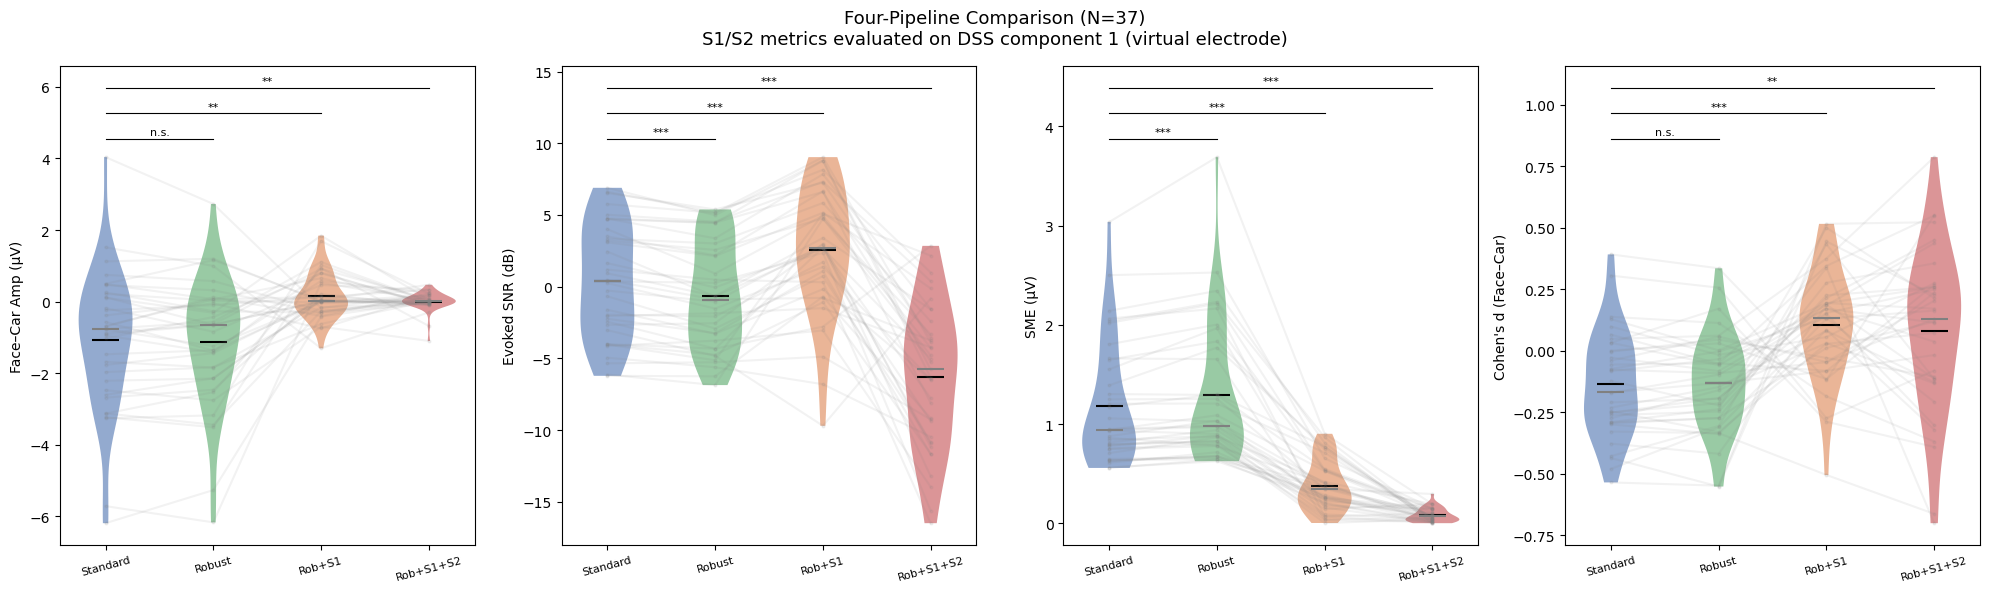

In [47]:
# ── Figure 3: Violin plots — 4 pipelines ─────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 6))

violin_metrics = [
    ("diff_amp", "Face–Car Amp (µV)"),
    ("snr", "Evoked SNR (dB)"),
    ("sme", "SME (µV)"),
    ("cohens_d", "Cohen's d (Face–Car)"),
]

colors = ["#4C72B0", "#55A868", "#DD8452", "#C44E52"]
labels = ["Standard", "Robust", "Rob+S1", "Rob+S1+S2"]
pipe_keys = ["std", "rob", "s1", "s2"]

for ax, (col, ylabel) in zip(axes, violin_metrics):
    data_list = [df[f"{col}_{pl}"].values for pl in pipe_keys]

    parts = ax.violinplot(data_list, positions=range(4),
                          showmeans=True, showmedians=True, showextrema=False)
    parts["cmeans"].set_color("black")
    parts["cmedians"].set_color("gray")
    for pc, c in zip(parts["bodies"], colors):
        pc.set_facecolor(c)
        pc.set_alpha(0.6)

    # Paired lines: Standard to each other
    for i in range(len(df)):
        vals = [data_list[j][i] for j in range(4)]
        ax.plot(range(4), vals, "o-", color="gray", alpha=0.1, markersize=2)

    # Significance: Standard vs each
    std_v = data_list[0]
    ymax = max(d.max() for d in data_list)
    ymin = min(d.min() for d in data_list)
    yr = ymax - ymin

    for j in range(1, 4):
        _, p = stats.ttest_rel(data_list[j], std_v)
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "n.s."
        y_pos = ymax + (0.05 + 0.07 * (j-1)) * yr
        ax.plot([0, j], [y_pos, y_pos], "k-", linewidth=0.8)
        ax.text(j/2, y_pos + 0.01*yr, sig, ha="center", fontsize=8)

    ax.set_xticks(range(4))
    ax.set_xticklabels(labels, fontsize=8, rotation=15)
    ax.set_ylabel(ylabel)

fig.suptitle(f"Four-Pipeline Comparison (N={len(df)})\n"
             "S1/S2 metrics evaluated on DSS component 1 (virtual electrode)",
             fontsize=13)
plt.tight_layout()
plt.savefig("fig3_robust_dss_violins.png", dpi=150, bbox_inches="tight")
plt.show()

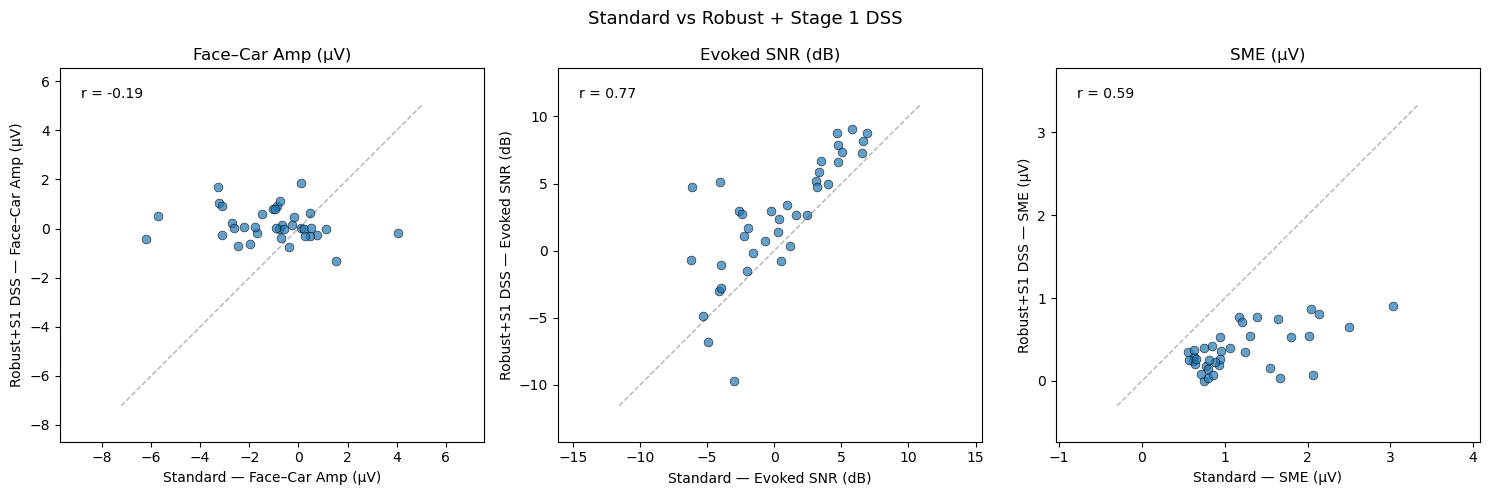

In [48]:
# ── Figure 4: Subject-level scatter (Standard vs Robust+S1 DSS) ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

scatter_metrics = [
    ("diff_amp_std", "diff_amp_s1", "Face–Car Amp (µV)"),
    ("snr_std", "snr_s1", "Evoked SNR (dB)"),
    ("sme_std", "sme_s1", "SME (µV)"),
]

for ax, (col_x, col_y, label) in zip(axes, scatter_metrics):
    x = df[col_x].values
    y = df[col_y].values
    ax.scatter(x, y, s=40, alpha=0.7, edgecolors="k", linewidth=0.5)

    lims = [min(x.min(), y.min()), max(x.max(), y.max())]
    margin = (lims[1] - lims[0]) * 0.1
    lims = [lims[0] - margin, lims[1] + margin]
    ax.plot(lims, lims, "k--", alpha=0.3, linewidth=1)

    ax.set_xlabel(f"Standard — {label}")
    ax.set_ylabel(f"Robust+S1 DSS — {label}")
    ax.set_title(label)
    ax.set_aspect("equal", adjustable="datalim")

    r, _ = stats.pearsonr(x, y)
    ax.text(0.05, 0.95, f"r = {r:.2f}", transform=ax.transAxes,
            fontsize=10, va="top")

fig.suptitle("Standard vs Robust + Stage 1 DSS", fontsize=13)
plt.tight_layout()
plt.savefig("fig4_robust_dss_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

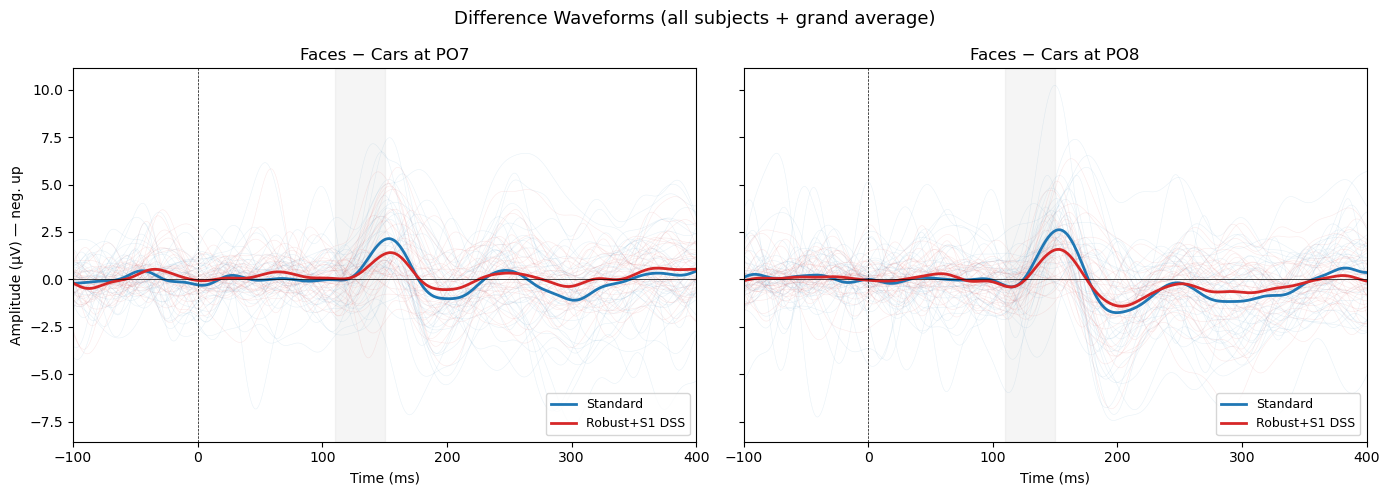

In [49]:
# ── Figure 5: Difference Waveforms — all subjects ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, ch in zip(axes, ROI_CHANNELS):
    ch_idx_std = all_evokeds["face_std"][0].ch_names.index(ch)
    times_ms = all_evokeds["face_std"][0].times * 1e3

    # Per-subject traces
    for i in range(len(all_evokeds["face_std"])):
        diff_std = (all_evokeds["face_std"][i].data[ch_idx_std]
                    - all_evokeds["car_std"][i].data[ch_idx_std]) * 1e6
        ax.plot(times_ms, -diff_std, color="tab:blue", alpha=0.1, linewidth=0.4)

    if "face_s1" in all_evokeds:
        ch_idx_s1 = all_evokeds["face_s1"][0].ch_names.index(ch)
        for i in range(len(all_evokeds["face_s1"])):
            diff_s1 = (all_evokeds["face_s1"][i].data[ch_idx_s1]
                       - all_evokeds["car_s1"][i].data[ch_idx_s1]) * 1e6
            ax.plot(times_ms, -diff_s1, color="tab:red", alpha=0.1, linewidth=0.4)

    # Grand averages
    ga_std_f = np.mean([e.data[ch_idx_std] for e in all_evokeds["face_std"]], axis=0) * 1e6
    ga_std_c = np.mean([e.data[ch_idx_std] for e in all_evokeds["car_std"]], axis=0) * 1e6
    ax.plot(times_ms, -(ga_std_f - ga_std_c), color="tab:blue", linewidth=2.0,
            label="Standard")

    if "face_s1" in all_evokeds and len(all_evokeds["face_s1"]) > 0:
        ga_s1_f = np.mean([e.data[ch_idx_s1] for e in all_evokeds["face_s1"]], axis=0) * 1e6
        ga_s1_c = np.mean([e.data[ch_idx_s1] for e in all_evokeds["car_s1"]], axis=0) * 1e6
        ax.plot(times_ms, -(ga_s1_f - ga_s1_c), color="tab:red", linewidth=2.0,
                label="Robust+S1 DSS")

    ax.axhline(0, color="k", linewidth=0.5)
    ax.axvline(0, color="k", linewidth=0.5, linestyle="--")
    ax.axvspan(110, 150, alpha=0.08, color="gray")
    ax.set_xlabel("Time (ms)")
    if ax == axes[0]:
        ax.set_ylabel("Amplitude (µV) — neg. up")
    ax.set_title(f"Faces − Cars at {ch}")
    ax.set_xlim(-100, 400)
    ax.legend(fontsize=9, loc="lower right")

fig.suptitle("Difference Waveforms (all subjects + grand average)", fontsize=13)
plt.tight_layout()
plt.savefig("fig5_robust_dss_difference.png", dpi=150, bbox_inches="tight")
plt.show()

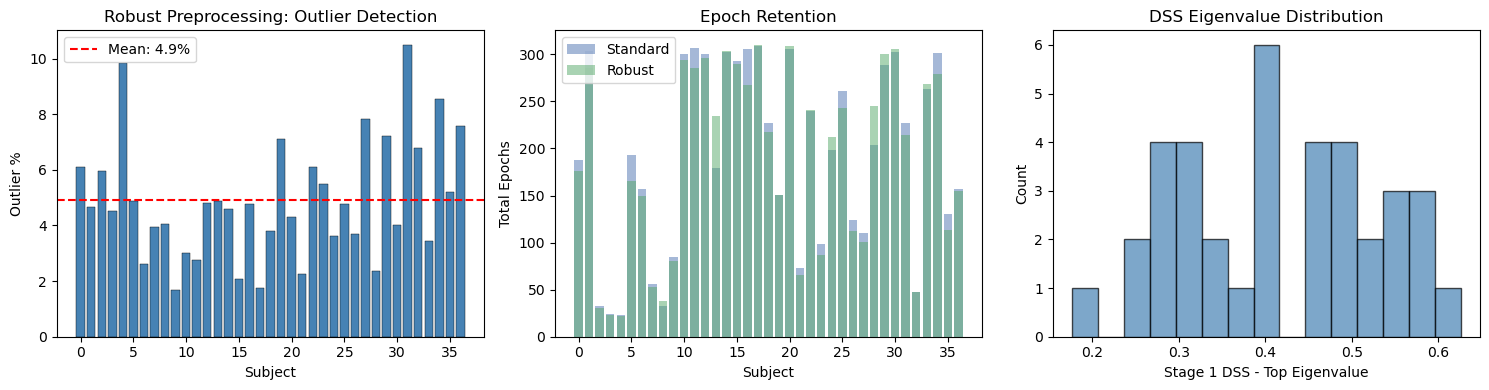

In [50]:
# ── Figure 6: Preprocessing statistics ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Outlier percentage per subject
ax = axes[0]
ax.bar(range(len(df)), df["pct_outlier"].values, color="steelblue",
       edgecolor="k", linewidth=0.3)
ax.set_xlabel("Subject")
ax.set_ylabel("Outlier %")
ax.set_title("Robust Preprocessing: Outlier Detection")
ax.axhline(df["pct_outlier"].mean(), color="red", linestyle="--",
           label=f"Mean: {df['pct_outlier'].mean():.1f}%")
ax.legend()

# Trial retention
ax = axes[1]
for pl, col, label in [
    ("std", "#4C72B0", "Standard"),
    ("rob", "#55A868", "Robust"),
]:
    n_face = df[f"n_face_{pl}"].values if f"n_face_{pl}" in df else None
    n_car = df[f"n_car_{pl}"].values if f"n_car_{pl}" in df else None
    if n_face is not None and n_car is not None:
        total = n_face + n_car
        ax.bar(range(len(df)), total, alpha=0.5, color=col, label=label)

ax.set_xlabel("Subject")
ax.set_ylabel("Total Epochs")
ax.set_title("Epoch Retention")
ax.legend()

# DSS eigenvalue distribution
ax = axes[2]
if "dss_ev1_s1" in df:
    ax.hist(df["dss_ev1_s1"].values, bins=15, color="steelblue",
            edgecolor="k", alpha=0.7)
    ax.set_xlabel("Stage 1 DSS - Top Eigenvalue")
    ax.set_ylabel("Count")
    ax.set_title("DSS Eigenvalue Distribution")

plt.tight_layout()
plt.savefig("fig6_robust_dss_stats.png", dpi=150, bbox_inches="tight")
plt.show()

## 7b. Component-Space Evaluation

DSS projects 30-channel data through K components and back. Evaluating re-projected data
with sensor-space metrics (GFP, ROI amplitude) mechanically reduces values because
~20 dimensions are zeroed out — a **rank-reduction artifact**, not a real degradation.

**Solution above:** All S1 and S2 metrics are now computed on **DSS component 1** (the "virtual
electrode" that maximally captures the evoked response), scaled to equivalent µV at PO7/PO8
using the mixing matrix: `amplitude_µV = mixing[ROI, 0] × component_value × 1e6`.
This makes amplitudes, SNR, SME, and Cohen's d directly comparable across pipelines.

The plots below confirm DSS component 1 captures the N170 evoked response and
show the per-component SNR breakdown.

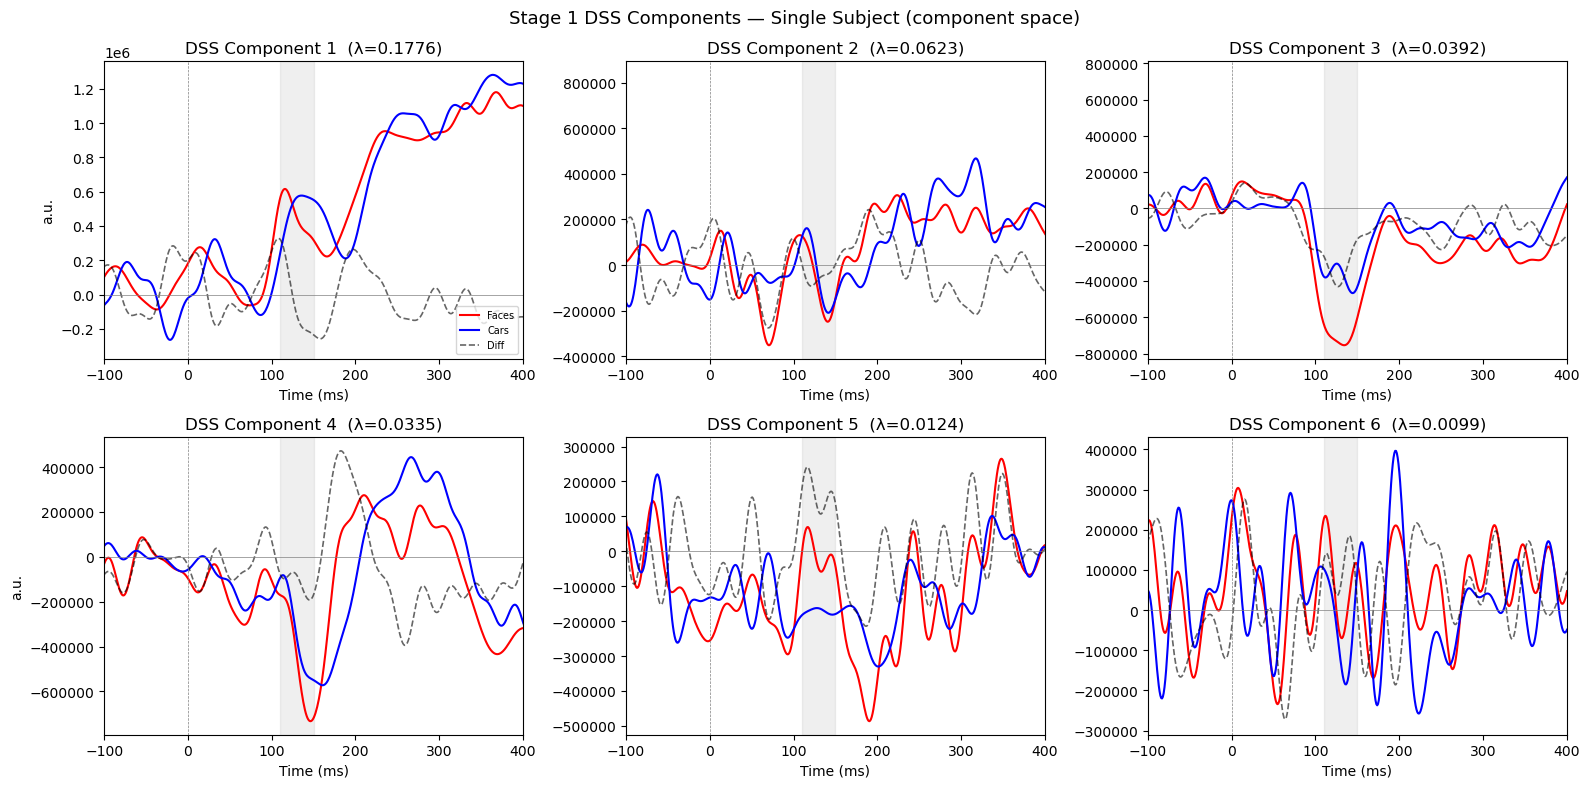

In [51]:
# ══════════════════════════════════════════════════════════════════════
# Diagnostic: Component-space evaluation on the single subject
# (result_s1, epochs_face, epochs_car are still in kernel from §4)
# ══════════════════════════════════════════════════════════════════════

# --- DSS component time courses ---
# Project single-trial epochs into Stage 1 DSS component space
comp_face = np.array([result_s1.filters @ ep for ep in data_face])  # (n_trials, n_comp, n_t)
comp_car  = np.array([result_s1.filters @ ep for ep in data_car])

# Evoked in component space
comp_face_avg = comp_face.mean(axis=0)  # (n_comp, n_t)
comp_car_avg  = comp_car.mean(axis=0)

times_ms_loc = epochs_face.times * 1000

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for k in range(6):
    ax = axes.flat[k]
    ax.plot(times_ms_loc, comp_face_avg[k] * 1e6, 'r-', lw=1.5, label='Faces')
    ax.plot(times_ms_loc, comp_car_avg[k] * 1e6, 'b-', lw=1.5, label='Cars')
    ax.plot(times_ms_loc, (comp_face_avg[k] - comp_car_avg[k]) * 1e6,
            'k--', lw=1.2, alpha=0.6, label='Diff')
    ax.axvspan(110, 150, alpha=0.12, color='gray')
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5, ls='--')
    ax.set_xlim(-100, 400)
    ax.set_title(f'DSS Component {k+1}  (λ={result_s1.eigenvalues[k]:.4f})')
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('a.u.' if k % 3 == 0 else '')
    if k == 0:
        ax.legend(fontsize=7, loc='lower right')

fig.suptitle('Stage 1 DSS Components — Single Subject (component space)', fontsize=13)
plt.tight_layout()
plt.show()

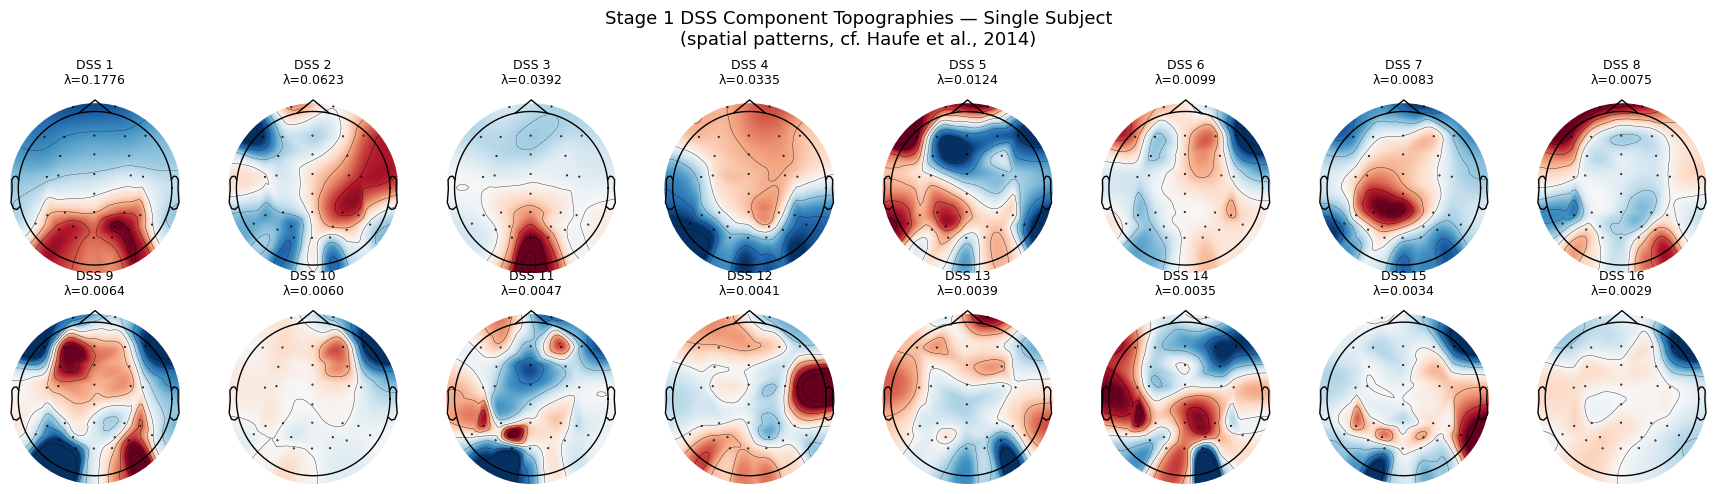

In [33]:
# ══════════════════════════════════════════════════════════════════════
# DSS Component Topographies (like ICA topomap plots)
# ══════════════════════════════════════════════════════════════════════
# result_s1.patterns : (n_ch, n_comp) — spatial patterns (Haufe et al., 2014)
# These show the scalp distribution of each DSS component, analogous to
# ICA component topographies.

n_show = min(result_s1.patterns.shape[1], 16)  # show up to 16 components
n_cols = min(n_show, 8)
n_rows = int(np.ceil(n_show / n_cols))

rename_map = {"FP1": "Fp1", "FP2": "Fp2"}

fig, axes = plt.subplots(n_rows, n_cols, figsize=(2.2 * n_cols, 2.5 * n_rows))
if n_rows == 1:
    axes = axes[np.newaxis, :]
if n_cols == 1:
    axes = axes[:, np.newaxis]

for k in range(n_show):
    ax = axes.flat[k]

    # Build a minimal EvokedArray for this component's pattern
    pattern_data = result_s1.patterns[:, k:k+1]  # (n_ch, 1)

    info = mne.create_info(
        ch_names=list(epochs_face.ch_names),
        sfreq=epochs_face.info["sfreq"],
        ch_types="eeg"
    )
    ev_pat = mne.EvokedArray(pattern_data, info, tmin=0.0)

    # Fix channel names for montage
    renames = {old: new for old, new in rename_map.items()
               if old in ev_pat.ch_names}
    if renames:
        ev_pat.rename_channels(renames)
    ev_pat.set_montage(montage, on_missing="ignore")

    ev_pat.plot_topomap(
        times=[0.0], axes=ax, show=False,
        colorbar=False, time_unit="s",
        scalings=1.0,  # patterns are unitless
    )
    ax.set_title(f"DSS {k+1}\nλ={result_s1.eigenvalues[k]:.4f}", fontsize=9)

# Hide unused axes
for k in range(n_show, n_rows * n_cols):
    axes.flat[k].set_visible(False)

fig.suptitle(
    f"Stage 1 DSS Component Topographies — Single Subject\n"
    f"(spatial patterns, cf. Haufe et al., 2014)",
    fontsize=13
)
plt.tight_layout()
plt.savefig("fig_dss_component_topographies.png", dpi=150, bbox_inches="tight")
plt.show()

## 7c. DSS vs ICA — Component Topographies & Runtime Comparison

We compare the DSS decomposition (Stage 1) against three standard ICA methods
available in MNE-Python:

| Method | Algorithm | Notes |
|--------|-----------|-------|
| **DSS** | Generalized eigenvalue (supervised) | Maximizes evoked reproducibility — **knows the bias function** |
| **FastICA** | Fixed-point iteration (unsupervised) | Maximizes non-Gaussianity |
| **Infomax** | Extended Infomax (unsupervised) | Maximizes information transfer |
| **Picard** | Preconditioned ICA (unsupervised) | Fast, numerically stable Infomax variant |

Key difference: DSS is **supervised** — it uses the evoked structure (trial-average)
to find optimal components. ICA is **blind** — it finds statistically independent sources
without knowing what the signal of interest looks like.

In [38]:
# ══════════════════════════════════════════════════════════════════════
# DSS vs ICA — Fit all methods, time them, compare topographies
# ══════════════════════════════════════════════════════════════════════
import time as _time

rename_map_topo = {"FP1": "Fp1", "FP2": "Fp2"}
n_components_show = 8   # show top 8 components per method
n_ica_comp = 15         # fewer ICA components → much faster

# ── 1. Time DSS ──────────────────────────────────────────────────
t0 = _time.perf_counter()
_d_face = epochs_face.get_data(copy=True)
_d_car = epochs_car.get_data(copy=True)
_d_all = np.concatenate([_d_face, _d_car], axis=0)
_n_all, _n_ch, _n_t = _d_all.shape
_d2 = _d_all.transpose(1, 0, 2).reshape(_n_ch, -1)
_C0 = compute_covariance(_d2)
_avg = _d_all.mean(axis=0)
_avg_t = np.tile(_avg, (1, _n_all))
_C1 = compute_covariance(_avg_t)
_res_dss = compute_dss(_C0, _C1, n_components=_n_ch)
dss_time = _time.perf_counter() - t0
print(f"{'DSS':<12s}: {dss_time:>7.3f} s  ({_n_ch} components, closed-form)")

# ── 2. Fit ICA on EPOCHS (same data as DSS — fair comparison) ────
all_epochs = mne.concatenate_epochs([epochs_face, epochs_car])

ica_methods = ["fastica", "infomax", "picard"]
ica_results = {}
ica_times = {}

for method in ica_methods:
    try:
        ica = mne.preprocessing.ICA(
            n_components=n_ica_comp,
            method=method,
            max_iter=500,
            random_state=42,
        )
        t0 = _time.perf_counter()
        ica.fit(all_epochs, verbose=False)
        elapsed = _time.perf_counter() - t0
        ica_results[method] = ica
        ica_times[method] = elapsed
        print(f"{method:<12s}: {elapsed:>7.3f} s  ({ica.n_components_} components, iterative)")
    except Exception as e:
        print(f"{method:<12s}: FAILED — {e}")

# ── 3. Collect topographies ──────────────────────────────────────
all_methods = {}
all_times = {}

all_methods["DSS"] = _res_dss.patterns[:, :n_components_show]
all_times["DSS"] = dss_time

for method, ica in ica_results.items():
    # get_components() → (n_ica_comp, n_channels); we need (n_channels, n_comp)
    comps = ica.get_components()  # (n_ica_comp, n_channels)
    n_avail = min(n_components_show, comps.shape[0])
    all_methods[method.capitalize()] = comps[:n_avail, :].T  # (n_channels, n_avail)
    all_times[method.capitalize()] = ica_times[method]

n_methods = len(all_methods)
method_names = list(all_methods.keys())

print(f"\n✓ {n_methods} methods ready for comparison")
print(f"  DSS is {min(ica_times.values()) / dss_time:.0f}–"
      f"{max(ica_times.values()) / dss_time:.0f}× faster than ICA")

DSS         :   0.166 s  (30 components, closed-form)
Not setting metadata
175 matching events found
Applying baseline correction (mode: mean)


C:\Users\s\AppData\Local\Temp\ipykernel_14296\1928449026.py:26: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  all_epochs = mne.concatenate_epochs([epochs_face, epochs_car])
C:\Users\s\AppData\Local\Temp\ipykernel_14296\1928449026.py:41: RuntimeWarning: The epochs you passed to ICA.fit() were baseline-corrected. However, we suggest to fit ICA only on data that has been high-pass filtered, but NOT baseline-corrected.
  ica.fit(all_epochs, verbose=False)


fastica     :   2.305 s  (15 components, iterative)


C:\Users\s\AppData\Local\Temp\ipykernel_14296\1928449026.py:41: RuntimeWarning: The epochs you passed to ICA.fit() were baseline-corrected. However, we suggest to fit ICA only on data that has been high-pass filtered, but NOT baseline-corrected.
  ica.fit(all_epochs, verbose=False)


infomax     :  28.753 s  (15 components, iterative)


C:\Users\s\AppData\Local\Temp\ipykernel_14296\1928449026.py:41: RuntimeWarning: The epochs you passed to ICA.fit() were baseline-corrected. However, we suggest to fit ICA only on data that has been high-pass filtered, but NOT baseline-corrected.
  ica.fit(all_epochs, verbose=False)


picard      :   3.784 s  (15 components, iterative)

✓ 4 methods ready for comparison
  DSS is 14–173× faster than ICA


DSS patterns shape: (30, 8)
fastica get_components() shape: (30, 15)
  → stored as (30, 8)
infomax get_components() shape: (30, 15)
  → stored as (30, 8)
picard get_components() shape: (30, 15)
  → stored as (30, 8)


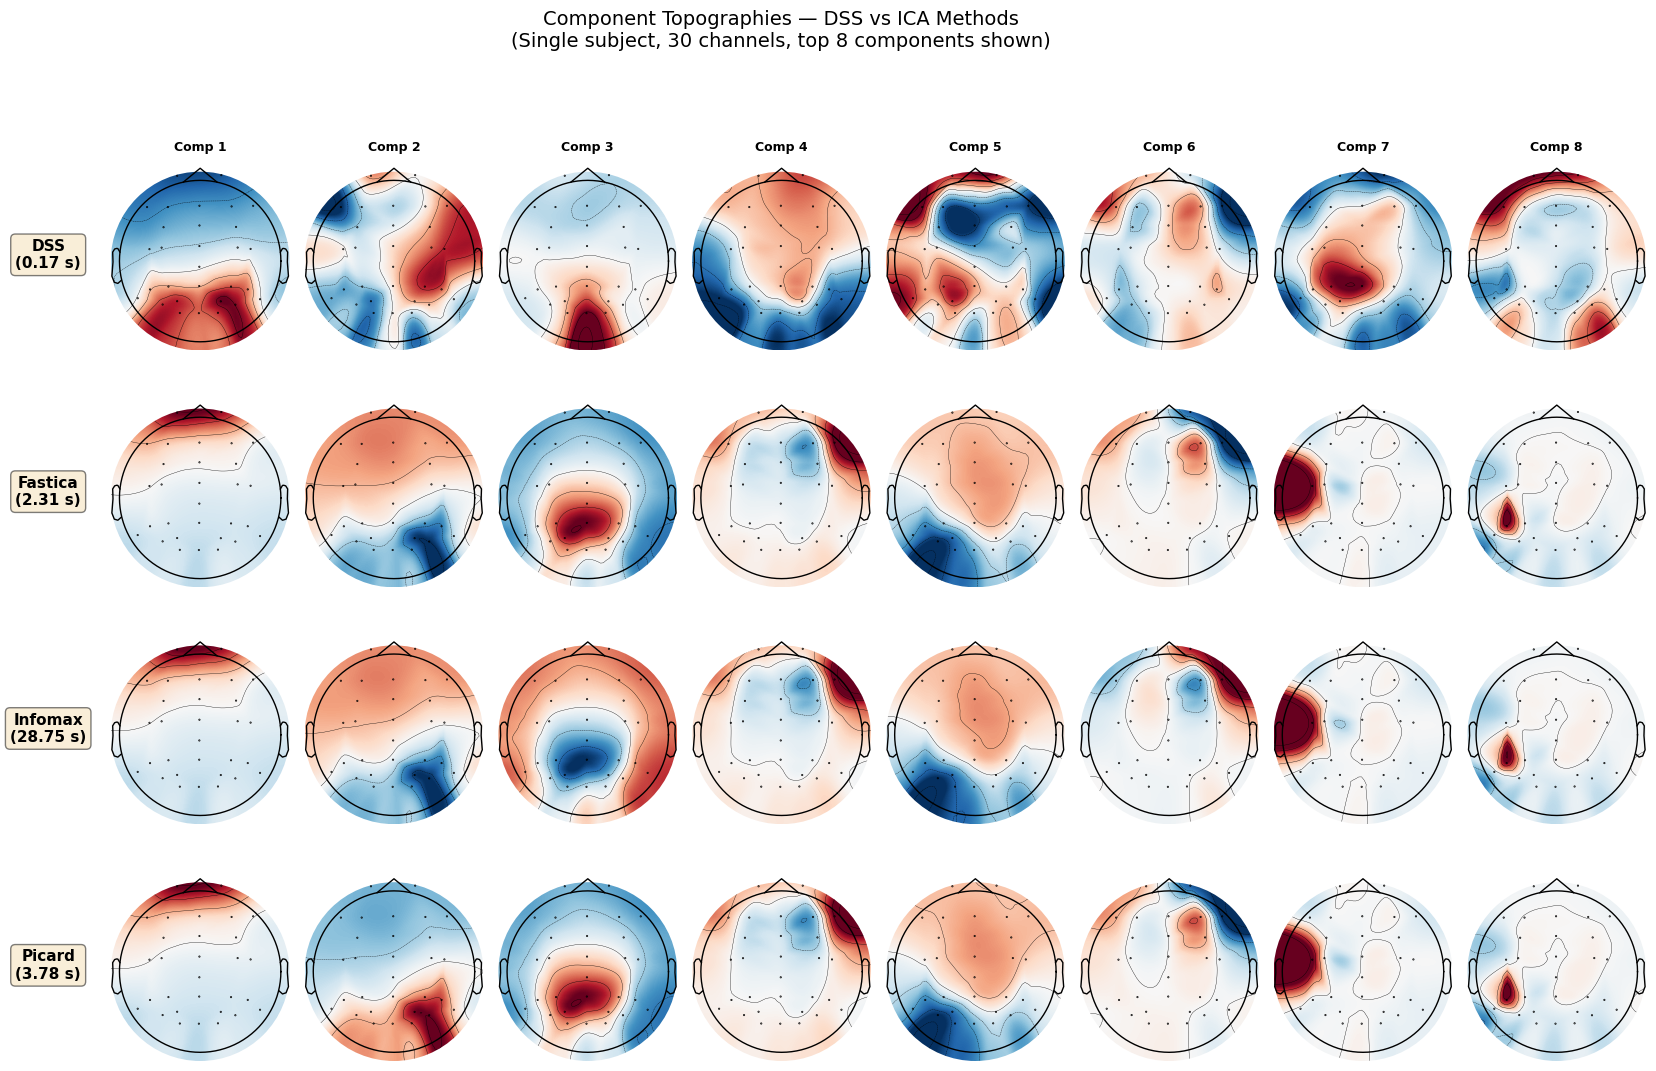

In [40]:
# ══════════════════════════════════════════════════════════════════════
# Figure: Side-by-side component topographies — DSS vs ICA methods
# ══════════════════════════════════════════════════════════════════════

# Rebuild patterns dict with guaranteed (n_ch, n_show) shape
n_ch_eeg = len(epochs_face.ch_names)
topo_patterns = {}

# DSS patterns: already (n_ch, n_comp)
topo_patterns["DSS"] = _res_dss.patterns[:, :n_components_show]
print(f"DSS patterns shape: {topo_patterns['DSS'].shape}")

for method, ica_obj in ica_results.items():
    # get_components() returns (n_components, n_channels) — rows are components
    gc = ica_obj.get_components()  # (n_ica_comp, n_ch_eeg)
    print(f"{method} get_components() shape: {gc.shape}")

    # We need (n_ch_eeg, n_show) — each column is a component's scalp map
    if gc.shape[0] == n_ch_eeg:
        # Already (n_ch, n_comp) — unlikely but handle it
        topo_patterns[method.capitalize()] = gc[:, :n_components_show]
    else:
        # Standard: (n_comp, n_ch) → transpose
        n_avail = min(n_components_show, gc.shape[0])
        topo_patterns[method.capitalize()] = gc[:n_avail, :].T  # (n_ch, n_avail)

    print(f"  → stored as {topo_patterns[method.capitalize()].shape}")

method_names_topo = list(topo_patterns.keys())
n_methods_topo = len(method_names_topo)

fig, axes = plt.subplots(
    n_methods_topo, n_components_show,
    figsize=(2.2 * n_components_show, 2.8 * n_methods_topo),
)
if n_methods_topo == 1:
    axes = axes[np.newaxis, :]

for row, method_name in enumerate(method_names_topo):
    patterns = topo_patterns[method_name]  # (n_ch_eeg, n_avail)
    n_avail = patterns.shape[1]

    for col in range(n_components_show):
        ax = axes[row, col]

        if col >= n_avail:
            ax.set_visible(False)
            continue

        pattern_vec = patterns[:, col:col+1]  # (n_ch_eeg, 1)

        info = mne.create_info(
            ch_names=list(epochs_face.ch_names),
            sfreq=epochs_face.info["sfreq"],
            ch_types="eeg",
        )
        ev_tmp = mne.EvokedArray(pattern_vec, info, tmin=0.0)

        renames = {old: new for old, new in rename_map_topo.items()
                   if old in ev_tmp.ch_names}
        if renames:
            ev_tmp.rename_channels(renames)
        ev_tmp.set_montage(montage, on_missing="ignore")

        ev_tmp.plot_topomap(
            times=[0.0], axes=ax, show=False,
            colorbar=False, time_unit="s", scalings=1.0,
        )

        if row == 0:
            ax.set_title(f"Comp {col+1}", fontsize=9, fontweight="bold")
        else:
            ax.set_title("", fontsize=1)

    # Row label
    axes[row, 0].text(
        -0.35, 0.5, f"{method_name}\n({all_times[method_name]:.2f} s)",
        transform=axes[row, 0].transAxes,
        fontsize=11, fontweight="bold", va="center", ha="center",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="wheat", alpha=0.5),
    )

fig.suptitle(
    f"Component Topographies — DSS vs ICA Methods\n"
    f"(Single subject, {n_ch_eeg} channels, top {n_components_show} components shown)",
    fontsize=14,
)
plt.tight_layout(rect=[0.06, 0.0, 1.0, 0.94])
plt.savefig("fig_dss_vs_ica_topographies.png", dpi=150, bbox_inches="tight")
plt.show()

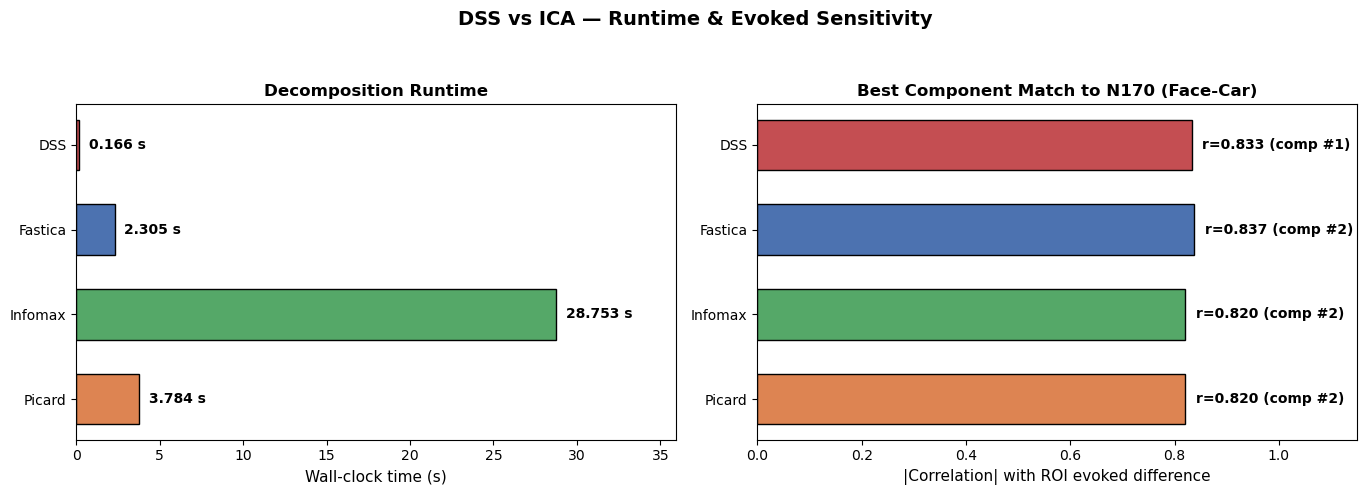


Method         Time (s)  Best comp   |r| evoked    Speedup
────────────────────────────────────────────────────────
DSS               0.166          1       0.8330          —
Fastica           2.305          2       0.8374 14× slower
Infomax          28.753          2       0.8203 173× slower
Picard            3.784          2       0.8204 23× slower


In [41]:
# ══════════════════════════════════════════════════════════════════════
# Figure: Runtime comparison + component correlation with evoked
# ══════════════════════════════════════════════════════════════════════

fig, (ax_time, ax_corr) = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: Runtime bar chart ───────────────────────────────────────
method_labels = list(all_times.keys())
runtimes = [all_times[m] for m in method_labels]
bar_colors = ["#C44E52", "#4C72B0", "#55A868", "#DD8452"][:len(method_labels)]

bars = ax_time.barh(method_labels, runtimes, color=bar_colors, edgecolor="k", height=0.6)
for bar, t in zip(bars, runtimes):
    ax_time.text(bar.get_width() + max(runtimes) * 0.02, bar.get_y() + bar.get_height()/2,
                 f"{t:.3f} s", va="center", fontsize=10, fontweight="bold")

ax_time.set_xlabel("Wall-clock time (s)", fontsize=11)
ax_time.set_title("Decomposition Runtime", fontsize=12, fontweight="bold")
ax_time.set_xlim(0, max(runtimes) * 1.25)
ax_time.invert_yaxis()

# ── Right: How well does each method's best component match the evoked? ──
evoked_diff = (epochs_face.average().data - epochs_car.average().data)
roi_idx_ref = [epochs_face.ch_names.index(ch) for ch in ROI_CHANNELS
               if ch in epochs_face.ch_names]
ref_signal = evoked_diff[roi_idx_ref].mean(axis=0)

best_corrs = {}
best_comp_idx = {}

for method_name in method_labels:
    if method_name == "DSS":
        filters = _res_dss.filters  # (n_comp, n_ch) — direct sensor-space unmixing
    else:
        ica_obj = ica_results[method_name.lower()]
        # ICA unmixing in sensor space = unmixing @ pca_components
        # unmixing_matrix_ is (n_ica_comp, n_ica_comp) in whitened space
        # pca_components_ is (n_ica_comp, n_ch) mapping sensors → PCA
        filters = ica_obj.unmixing_matrix_ @ ica_obj.pca_components_[:ica_obj.n_components_]

    # Evoked difference in component space
    ev_face_comp = filters @ epochs_face.average().data
    ev_car_comp = filters @ epochs_car.average().data
    comp_diff = ev_face_comp - ev_car_comp

    # Correlation of each component with ROI reference
    n_comp_available = comp_diff.shape[0]
    corrs = np.array([
        np.abs(np.corrcoef(comp_diff[c], ref_signal)[0, 1])
        for c in range(n_comp_available)
    ])

    best_idx = np.argmax(corrs)
    best_corrs[method_name] = corrs[best_idx]
    best_comp_idx[method_name] = best_idx + 1

corr_vals = [best_corrs[m] for m in method_labels]
comp_labels_text = [f"#{best_comp_idx[m]}" for m in method_labels]

bars2 = ax_corr.barh(method_labels, corr_vals, color=bar_colors, edgecolor="k", height=0.6)
for bar, r, cl in zip(bars2, corr_vals, comp_labels_text):
    ax_corr.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                 f"r={r:.3f} (comp {cl})", va="center", fontsize=10, fontweight="bold")

ax_corr.set_xlabel("|Correlation| with ROI evoked difference", fontsize=11)
ax_corr.set_title("Best Component Match to N170 (Face-Car)", fontsize=12, fontweight="bold")
ax_corr.set_xlim(0, 1.15)
ax_corr.invert_yaxis()

fig.suptitle("DSS vs ICA — Runtime & Evoked Sensitivity", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("fig_dss_vs_ica_runtime.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Summary table ─────────────────────────────────────────────────
print(f"\n{'Method':<12s} {'Time (s)':>10s} {'Best comp':>10s} {'|r| evoked':>12s} {'Speedup':>10s}")
print("─" * 56)
for m in method_labels:
    speedup = f"—" if m == "DSS" else f"{all_times[m] / dss_time:.0f}× slower"
    print(f"{m:<12s} {all_times[m]:>10.3f} {best_comp_idx[m]:>10d} {best_corrs[m]:>12.4f} {speedup:>10s}")

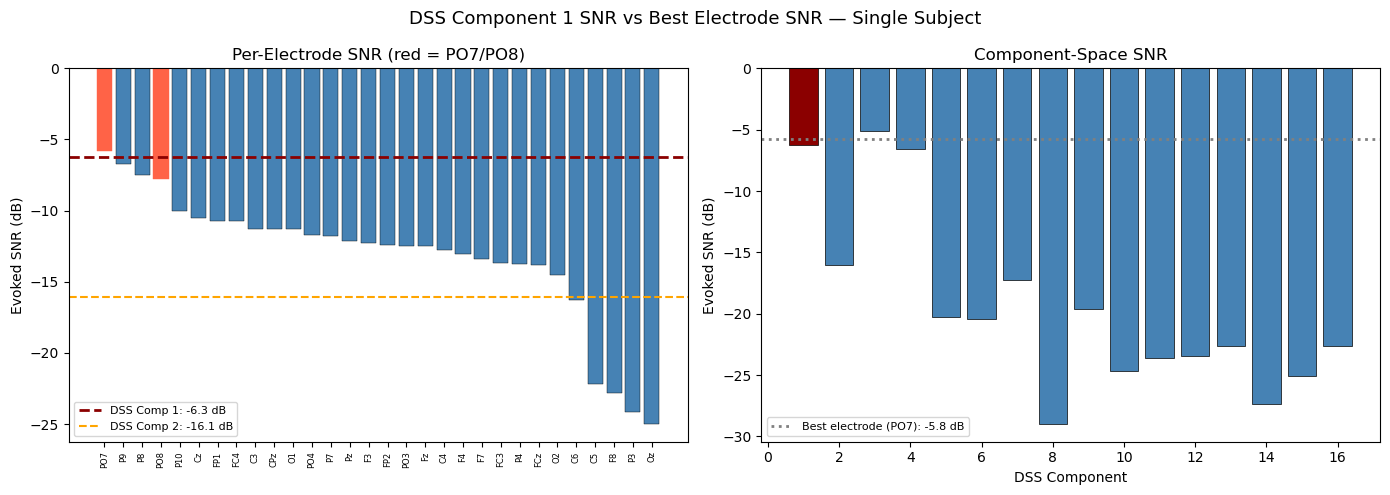


Best electrode: PO7 = -5.8 dB
DSS Component 1:          = -6.3 dB
Improvement:               = -0.5 dB

PO7 SNR: -5.8 dB
PO8 SNR: -7.7 dB


In [29]:
# ══════════════════════════════════════════════════════════════════════
# Component-space SNR vs Best-electrode SNR
# ══════════════════════════════════════════════════════════════════════
# The proper DSS evaluation: does DSS component 1 have higher
# trial-to-trial SNR than any individual electrode?

t_idx = np.where((epochs_face.times >= N170_WIN[0]) &
                 (epochs_face.times <= N170_WIN[1]))[0]

# --- Per-electrode SNR (in sensor space) ---
ch_names_loc = epochs_face.ch_names
n_ch_loc = len(ch_names_loc)
electrode_snr = np.zeros(n_ch_loc)

for c in range(n_ch_loc):
    face_ep = data_face[:, c, :]  # (n_trials, n_t)
    car_ep  = data_car[:, c, :]
    all_ep  = np.concatenate([face_ep, car_ep], axis=0)
    evoked  = all_ep.mean(axis=0)
    residuals = all_ep - evoked[np.newaxis, :]

    sig_pow = np.mean(evoked[t_idx]**2)
    noise_pow = np.mean(residuals[:, t_idx]**2)
    electrode_snr[c] = 10 * np.log10(sig_pow / max(noise_pow, 1e-30))

# --- Per-component SNR (in DSS space) ---
comp_all = np.concatenate([comp_face, comp_car], axis=0)  # (n_all, n_comp, n_t)
n_comp = comp_all.shape[1]
component_snr = np.zeros(n_comp)

for k in range(n_comp):
    comp_trials = comp_all[:, k, :]  # (n_all, n_t)
    comp_evoked = comp_trials.mean(axis=0)
    comp_resid  = comp_trials - comp_evoked[np.newaxis, :]

    sig_pow = np.mean(comp_evoked[t_idx]**2)
    noise_pow = np.mean(comp_resid[:, t_idx]**2)
    component_snr[k] = 10 * np.log10(sig_pow / max(noise_pow, 1e-30))

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: electrode SNR sorted
ax = axes[0]
order = np.argsort(electrode_snr)[::-1]
bars = ax.bar(range(n_ch_loc), electrode_snr[order],
              color='steelblue', edgecolor='k', linewidth=0.3)
# Highlight PO7/PO8
for idx_b, ch_idx in enumerate(order):
    if ch_names_loc[ch_idx] in ROI_CHANNELS:
        bars[idx_b].set_color('tomato')
ax.axhline(component_snr[0], color='darkred', ls='--', lw=2,
           label=f'DSS Comp 1: {component_snr[0]:.1f} dB')
ax.axhline(component_snr[1], color='orange', ls='--', lw=1.5,
           label=f'DSS Comp 2: {component_snr[1]:.1f} dB')
ax.set_xticks(range(n_ch_loc))
ax.set_xticklabels([ch_names_loc[i] for i in order], rotation=90, fontsize=6)
ax.set_ylabel('Evoked SNR (dB)')
ax.set_title('Per-Electrode SNR (red = PO7/PO8)')
ax.legend(fontsize=8)

# Component SNR
ax = axes[1]
colors_comp = ['darkred'] + ['steelblue'] * (n_comp - 1)
ax.bar(range(1, n_comp+1), component_snr, color=colors_comp,
       edgecolor='k', linewidth=0.5)
best_elec = electrode_snr.max()
ax.axhline(best_elec, color='gray', ls=':', lw=2,
           label=f'Best electrode ({ch_names_loc[order[0]]}): {best_elec:.1f} dB')
ax.set_xlabel('DSS Component')
ax.set_ylabel('Evoked SNR (dB)')
ax.set_title('Component-Space SNR')
ax.legend(fontsize=8)

fig.suptitle(f'DSS Component 1 SNR vs Best Electrode SNR — Single Subject', fontsize=13)
plt.tight_layout()
plt.show()

print(f"\nBest electrode: {ch_names_loc[order[0]]} = {best_elec:.1f} dB")
print(f"DSS Component 1:          = {component_snr[0]:.1f} dB")
print(f"Improvement:               = {component_snr[0] - best_elec:+.1f} dB")
print(f"\nPO7 SNR: {electrode_snr[ch_names_loc.index('PO7')]:.1f} dB")
print(f"PO8 SNR: {electrode_snr[ch_names_loc.index('PO8')]:.1f} dB")

## 8. Summary & Discussion

### Pipeline Architecture

This notebook implements a theoretically-motivated EEG pipeline directly from
two complementary papers by de Cheveigné and colleagues:

**Stage 1 — Robust Preprocessing** (de Cheveigné & Arzounian, 2018):
- **Robust detrending**: Weighted polynomial fitting that automatically
  detects and excludes glitches, avoiding the high-pass filtering artifacts
  documented extensively in the paper (Fig. 2–4)
- **Outlier detection**: Cross-channel projection identifies channel-specific
  artifacts based on mismatch from the multichannel model
- **Inpainting**: Corrupt segments are reconstructed from intact channels
  using the correlation structure estimated from clean data
- **Robust rereferencing**: Weighted average reference excludes corrupt samples

**Stage 2 — DSS / Joint Decorrelation** (de Cheveigné & Parra, 2014):
- **Stage 1 DSS**: Trial-average bias finds the most reproducible subspace
  (maximizes evoked power / total power)
- **Stage 2 DSS**: Within the reproducible subspace, a condition-contrast
  bias finds the face-selective components (maximizes face–car difference)

### Key Advantages Over Standard Processing

| Feature | Standard Pipeline | Robust + DSS Pipeline |
|---------|------------------|----------------------|
| Drift removal | High-pass filter (risk of ringing artifacts) | Robust detrending (immune to glitches) |
| Glitch handling | Epoch rejection (data loss) | Outlier detection + inpainting (data preserved) |
| Rereferencing | Standard average (glitch-sensitive) | Weighted average (glitch-immune) |
| Signal enhancement | None | DSS finds optimal spatial filters |
| Condition specificity | None | Two-stage DSS extracts condition-specific activity |

### Processing Order Rationale

Following de Cheveigné & Arzounian (2018), §Discussion:
> *If algorithm B is sensitive to an artifact that algorithm A can remove,*
> *then A should be applied before B.*

1. ZapLine+ → removes line noise (DSS and covariance are sensitive to 60 Hz)
2. Robust detrending → removes drifts (DSS is sensitive to slow trends)
3. Outlier detection + inpainting → fixes glitches (covariance estimation is sensitive to outliers)
4. Robust rereferencing → clean reference (DSS benefits from clean reference)
5. Mild filtering (0.1–30 Hz) → remove residual slow/fast components
6. Stage 1 DSS → find reproducible subspace
7. Stage 2 DSS → find condition-specific activity within that subspace

### References

- de Cheveigné, A., & Arzounian, D. (2018). Robust detrending, rereferencing,
  outlier detection, and inpainting for multichannel data. *NeuroImage*, 172, 903–912.
- de Cheveigné, A., & Parra, L. C. (2014). Joint decorrelation, a versatile
  tool for multichannel data analysis. *NeuroImage*, 98, 487–505.
- Kappenman, E. S., et al. (2021). ERP CORE: An open resource for human
  event-related potential research. *NeuroImage*, 225, 117465.
- Kessler, R., Enge, A., & Skeide, M. A. (2025). How EEG preprocessing
  shapes decoding performance. *Communications Biology*, 8, 1039.
- Särelä, J., & Valpola, H. (2005). Denoising source separation.
  *Journal of Machine Learning Research*, 6, 233–272.